# MammoLens: Breast Cancer Detection on Mammograms

**Author:** Ibrahim Tamilore Esther

This is my main analysis notebook. I take the CBIS-DDSM mammograms from the raw metadata through to a trained EfficientNet-B0, evaluate it separately in non-dense and dense breasts, and look at what the model attends to with Grad-CAM. Elsewhere in the project I call this run v1, and its outputs are saved in `initial_run/`.

> `README.md` explains all four runs I did and which one I am reporting as my main result.

> This is an academic prototype. It is not a medical device and it must not be used to make decisions about anyone's care.

<a id="abstract"></a>
## Abstract

This notebook is the record of my main MammoLens run. I set out to see whether an ImageNet-pretrained EfficientNet-B0 can tell benign from malignant findings on whole mammograms, and whether it does as well in dense breasts as in fatty ones. I linked the full mammograms in CBIS-DDSM to their case descriptions, which gave me 2857 unique images from 1460 patients, and split them into training (2052), validation (405) and test (400) sets with no patient in more than one set. I fine-tuned the network for 12 epochs at 224 by 224 pixels and scored the checkpoint with the best validation AUC (0.7543) once on the held-out test set. It reached an AUC of 0.754, with sensitivity 0.657 and specificity 0.745. Performance was lower in dense breasts: AUC 0.695 for BI-RADS C/D (N = 202) against 0.819 for A/B (N = 198). I also produced Grad-CAM maps for six test cases chosen by rule, to get some sense of which regions drive the malignant score. The main limitation is statistical. Everything here comes from one training run and a single test set of 400 images with no confidence intervals, so I treat the density gap as something to test further rather than as an established effect.

## Contents

- [Abstract](#abstract)
- [1 Setup and environment](#s1)
  - [1.1 Runtime and dependencies](#s1-1)
  - [1.2 Configuration](#s1-2)
- [2 Data acquisition and linkage](#s2)
  - [2.1 Extracting the CBIS-DDSM archive](#s2-1)
  - [2.2 Inspecting the raw metadata](#s2-2)
- [3 Preprocessing and patient-grouped split](#s3)
  - [3.1 Manifest construction and split](#s3-1)
  - [3.2 Image preprocessing and split composition](#s3-2)
  - [3.3 Local image cache](#s3-3)
- [4 Model and training](#s4)
  - [4.1 EfficientNet-B0 fine-tuning](#s4-1)
- [5 Evaluation](#s5)
  - [5.1 Test-set evaluation procedure](#s5-1)
  - [5.2 Aggregate performance](#s5-2)
  - [5.3 Density-stratified performance](#s5-3)
  - [5.4 Best-checkpoint evaluation and export](#s5-4)
  - [5.5 Density comparison chart](#s5-5)
  - [5.6 Supplementary checks](#s5-6)
    - [5.6.1 Per-image predictions](#s5-6-1)
    - [5.6.2 Discrimination on training, validation and test data](#s5-6-2)
    - [5.6.3 Hyperparameters](#s5-6-3)
    - [5.6.4 Data cleaning counts](#s5-6-4)
    - [5.6.5 Storage timing](#s5-6-5)
  - [5.7 Statistical analysis of the density gap](#s5-7)
    - [5.7.1 Bootstrap confidence intervals](#s5-7-1)
    - [5.7.2 Testing the density gap](#s5-7-2)
    - [5.7.3 Operating points at a specificity of 0.80](#s5-7-3)
    - [5.7.4 Calibration by density](#s5-7-4)
    - [5.7.5 Saving the results](#s5-7-5)
    - [References for Sections 5.6 and 5.7](#s5-7-refs)
- [6 Interpretability (Grad-CAM)](#s6)
  - [6.1 Curated Grad-CAM gallery](#s6-1)
- [7 Limitations](#s7)
- [8 References](#s8)

Figures and tables: [Table 1](#t1) raw metadata; [Table 2](#t2) realised split; [Table 3](#t3) split composition; [Table 4](#t4) test metrics; [Table 5](#t5) best-checkpoint test metrics; [Table 6](#t6) bootstrap confidence intervals; [Table 7](#t7) operating points; [Figure 1](#f1) density comparison; [Figure 2](#f2) Grad-CAM gallery; [Figure 3](#f3) calibration by density. Supplementary tables in Section 5.6: [Table S1](#ts1) AUC by split; [Table S2](#ts2) hyperparameters; [Table S3](#ts3) cleaning counts; [Table S4](#ts4) storage timing.

<a id="s1"></a>
## 1 Setup and environment

<a id="s1-1"></a>
### 1.1 Runtime and dependencies

I ran this on Google Colab with the project folder on Google Drive at `/content/drive/MyDrive/MammoLens`. The cell below mounts Drive, makes the project root the working directory and adds it to `sys.path` so I can import the modules in `src/` as a package. Then it installs what is listed in `requirements.txt` and prints the PyTorch build (Paszke et al., 2019) and the GPU. I bounded the requirements from below only, so that pip keeps Colab's preinstalled CUDA build of PyTorch instead of replacing it.

Keeping the data, checkpoints and results on Drive rather than on the Colab machine was a deliberate trade. Colab sessions are temporary and drop without warning, and anything written only under `/content` disappears with them. Drive is slower to read from, which Section 3.3 works around for the images, but a checkpoint written to Drive at the end of an epoch survives a disconnect. I put the reusable code in `src/` for a related reason: the same training function can then be run from the command line with `python -m src.train`, and the notebook stays short enough to actually read.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
PROJECT_DIR = '/content/drive/MyDrive/MammoLens'
assert os.path.isdir(PROJECT_DIR), f'Project not found at {PROJECT_DIR} — upload the repo there.'
os.chdir(PROJECT_DIR)
sys.path.append(PROJECT_DIR)  # so that `import src...` finds my modules

!pip install -q -r requirements.txt

import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('No GPU detected — set Runtime → Change runtime type → GPU.')

Mounted at /content/drive
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


The run used PyTorch `2.11.0+cu128` on a single Tesla T4. I record the versions because some GPU kernels are not deterministic and they behave differently across hardware generations, so anyone rerunning this on a different GPU may not match my printed metrics to the third decimal place even with the same seed. This cell's execution count is 2 while most of the later cells have none at all, which tells me the outputs in this notebook came from more than one Colab session. I come back to that in Section 7.

<a id="s1-2"></a>
### 1.2 Configuration

Every path and hyperparameter comes from `configs/config.yaml` through `src.config.load_config`, and `ensure_dirs` creates the checkpoint and log folders if they are missing. I kept all the tunable values in one YAML file rather than scattering them through the notebook and the modules, so that changing a setting leaves a trace in one place and the training code reads exactly what the file says. The cell prints the four settings I need most often when reading the results below.

In [4]:
from src.config import load_config, ensure_dirs

cfg = load_config('configs/config.yaml')
ensure_dirs(cfg)
print('Batch size:', cfg.train.batch_size)
print('Learning rate:', cfg.train.learning_rate)
print('Epochs:', cfg.train.epochs)
print('Image size:', cfg.data.image_size)
# This run's artefacts were moved to initial_run/ when the folders were renamed,
# so the configured paths are redirected there rather than to the shared workspace.
cfg.paths.checkpoint_dir = os.path.join(cfg.paths.drive_root, 'initial_run', 'checkpoints')
print('Checkpoints ->', cfg.paths.checkpoint_dir)

Batch size: 32
Learning rate: 0.0003
Epochs: 12
Image size: 224
Checkpoints -> /content/drive/MyDrive/MammoLens/checkpoints


Training used a batch size of 32, a learning rate of 0.0003 and 12 epochs, with images resized to 224 pixels square and checkpoints written to `/content/drive/MyDrive/MammoLens/checkpoints`. The input size matches the resolution EfficientNet-B0 was designed and pretrained at (Tan and Le, 2019). What that resolution costs me on small lesions comes up in Sections 3.2 and 7. The configuration file holds several more settings that this cell does not print, including the optimiser, weight decay, the learning-rate schedule, dropout, mixed precision and early stopping; I describe them in Section 4.1 and list them with their values in Table S2.

<a id="s2"></a>
## 2 Data acquisition and linkage

<a id="s2-1"></a>
### 2.1 Extracting the CBIS-DDSM archive

The images come from CBIS-DDSM, the Curated Breast Imaging Subset of the Digital Database for Screening Mammography (Heath et al., 2001; Lee et al., 2017). I have it as a single `archive.zip` of JPEG conversions together with CSV metadata. The cell extracts the archive into `data/` only if `data/jpeg` does not already exist, then lists the top level of `data/`, counts the JPEG files and lists every CSV it finds.

I check for the `jpeg` subfolder rather than for `data/` itself on purpose. Testing `data/` alone would let a half-created empty folder pass as a finished extraction and quietly block the unzip, which is the kind of failure that would have cost me an afternoon. After the first run the extraction is skipped entirely: the archive is several gigabytes and unpacking it over the Drive mount at the start of every session would eat most of the session.

In [ ]:
# Mount Drive (skip if already mounted), then extract archive.zip into data/
# ONLY if data/ isn't already populated. Re-extracting ~5 GB every session
# would waste most of my Colab time.
import os, zipfile, glob

if not os.path.isdir('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/MammoLens'
ARCHIVE     = os.path.join(PROJECT_DIR, 'archive.zip')
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')

# I treat data/ as ready only if the jpeg tree is actually inside it, so a
# half-made empty folder cannot silently block the extraction.
if os.path.isdir(os.path.join(DATA_DIR, 'jpeg')):
    print(f'data/ already extracted at {DATA_DIR} - skipping unzip.')
else:
    assert os.path.isfile(ARCHIVE), f'archive.zip not found at {ARCHIVE}'
    os.makedirs(DATA_DIR, exist_ok=True)
    print(f'Extracting {ARCHIVE} -> {DATA_DIR} (one-time, may take a while)...')
    with zipfile.ZipFile(ARCHIVE) as z:
        z.extractall(DATA_DIR)
    print('Done.')

print('\nTop level of data/:')
for name in sorted(os.listdir(DATA_DIR)):
    p = os.path.join(DATA_DIR, name)
    print(f'  [{"dir " if os.path.isdir(p) else "file"}] {name}')

n_jpg = len(glob.glob(os.path.join(DATA_DIR, 'jpeg', '*', '*.jpg')))
print(f'\nJPEG images found: {n_jpg}')

csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, '**', '*.csv'), recursive=True))
print(f'\nCSV files ({len(csv_paths)}):')
for c in csv_paths:
    print('  ', os.path.relpath(c, DATA_DIR))

data/ already extracted at /content/drive/MyDrive/MammoLens/data - skipping unzip.

Top level of data/:
  [dir ] csv
  [dir ] jpeg
  [file] test.csv
  [file] train.csv
  [file] val.csv

JPEG images found: 10237

CSV files (9):
   csv/calc_case_description_test_set.csv
   csv/calc_case_description_train_set.csv
   csv/dicom_info.csv
   csv/mass_case_description_test_set.csv
   csv/mass_case_description_train_set.csv
   csv/meta.csv
   test.csv
   train.csv
   val.csv


The archive was already extracted, so nothing was unzipped. Alongside the `csv` and `jpeg` folders from the archive, `data/` also holds the three manifests (`train.csv`, `val.csv`, `test.csv`) that Section 3.1 writes, which tells me this output was captured after I had already built the manifests at least once.

The 10237 JPEG files counted here are not all candidates for training. CBIS-DDSM stores full mammograms, lesion crops and ROI masks side by side, which Table 1c and 1f show in Section 2.2, and I only want the full mammograms. Nine CSV files turned up: the six original metadata files in `csv/` and my three manifests.

<a id="s2-2"></a>
### 2.2 Inspecting the raw metadata

Column names are not consistent across the CBIS-DDSM metadata files, so before any of my code depends on them the cell prints each raw CSV's column list and first three rows. I wrote the manifest builder in Section 3.1 against this output. Reading the schema first costs me one cell; guessing it risks a `KeyError` at best, and at worst quietly reading a similarly named column that holds something else entirely.

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

CSV_DIR = os.path.join(DATA_DIR, 'csv')

# Look at every CSV's columns and first rows BEFORE assuming any names:
# they differ between versions of this dataset.
for c in sorted(glob.glob(os.path.join(CSV_DIR, '*.csv'))):
    df = pd.read_csv(c, nrows=3)
    print('=' * 90)
    print(os.path.basename(c))
    print('  columns:', list(df.columns))
    display(df.head(3))

calc_case_description_test_set.csv
  columns: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00038,2,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_CC/1.3.6.1.4.1.9590.100...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00038,2,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_MLO/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00038,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....


calc_case_description_train_set.csv
  columns: ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...


dicom_info.csv
  columns: ['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue', 'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID', 'StudyTime']


...

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...


mass_case_description_train_set.csv
  columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...


meta.csv
  columns: ['SeriesInstanceUID', 'StudyInstanceUID', 'Modality', 'SeriesDescription', 'BodyPartExamined', 'SeriesNumber', 'Collection', 'Visibility', 'ImageCount']


,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


<a id="t1"></a>
**Table 1.** The first three rows of each raw CBIS-DDSM metadata file, in the order printed above: (a) `calc_case_description_test_set.csv`, (b) `calc_case_description_train_set.csv`, (c) `dicom_info.csv`, (d) `mass_case_description_test_set.csv`, (e) `mass_case_description_train_set.csv` and (f) `meta.csv`. The long path and UID strings are truncated by pandas.

Table 1 answers the three questions my manifest builder has to get right.

The label comes from the `pathology` column, which takes the values `BENIGN`, `BENIGN_WITHOUT_CALLBACK` and `MALIGNANT` in the rows shown (Table 1a and 1b). I map `MALIGNANT` to 1 and both benign values to 0. `BENIGN_WITHOUT_CALLBACK` means a finding judged benign where the patient was not recalled for further work-up (Lee et al., 2017), so grouping it with `BENIGN` matches what it means clinically. Keeping it as a third class would only split my benign cases for no gain in a binary task.

Breast density is stored under two different names: `breast_density` in the mass files (Table 1d and 1e) and `breast density`, with a space, in the calcification files (Table 1a and 1b). So rather than naming a column, my builder picks whichever one contains the string "density".

Linking each case to its image is the awkward part. The `image file path` column in the case files gives a relative DICOM path, and those DICOM files are not in this JPEG distribution at all. `dicom_info.csv` (Table 1c) bridges the gap: its `image_path` column points at the actual JPEG, and its `SeriesInstanceUID` turns up as one component of the case file's DICOM path, so I can join the two on that UID. The same file's `SeriesDescription` separates `full mammogram images` from `cropped images`, and `meta.csv` (Table 1f) shows a third type, `ROI mask images`. Filtering on `SeriesDescription` is what restricts my dataset to whole mammograms.

Table 1c also shows the scale of what I am classifying. The full mammogram in its second row is 6256 pixels high and 3526 wide, against the 224-pixel input the network gets.

One more thing: the case paths carry prefixes such as `Calc-Test_` and `Calc-Training_` (Table 1a and 1b), which record the original CBIS-DDSM train and test assignment. I do not keep that assignment, and Section 3.1 explains why.

<a id="s3"></a>
## 3 Preprocessing and patient-grouped split

<a id="s3-1"></a>
### 3.1 Manifest construction and split

This cell turns the four case files into my three manifests (`data/train.csv`, `data/val.csv`, `data/test.csv`), each with the columns `image_path`, `label`, `density` and `patient_id`. It works in six steps.

1. Build a lookup from `SeriesInstanceUID` to relative JPEG path, using only the `dicom_info.csv` rows whose `SeriesDescription` is `full mammogram images`.
2. Read all four case files, detect each file's density and path columns, binarise `pathology`, and resolve every DICOM path to a JPEG through the lookup.
3. Drop rows whose path could not be resolved, whose density is missing or outside BI-RADS 1 to 4, or whose JPEG is not on disk.
4. Collapse to one row per image. If an image has several abnormalities I label it malignant when any of them is malignant, and take density and `patient_id` from its first row.
5. Split with scikit-learn's `StratifiedGroupKFold` (Pedregosa et al., 2011), grouped on `patient_id` and stratified on a combined label and density key. Fold 0 of a 7-fold split becomes my test set; fold 0 of a 6-fold split of the remainder becomes validation.
6. Write the manifests, print the realised sizes and balance, and assert that no `patient_id` appears in more than one split.

The patient grouping is the most important decision in this notebook. CBIS-DDSM usually holds two views, CC and MLO, of the same breast, which the paired rows for `P_00038` and `P_00005` in Table 1 show, and one patient can contribute several images. If I split at image level, one view of a lesion would end up in training and the other in test, and the model could score well partly by recognising a breast it had already seen. That kind of leakage inflates test metrics without making the model any better (Kaufman et al., 2012). Grouping on `patient_id` closes that route, and the assertion at the end turns the guarantee into a check that fails loudly if I ever break it.

Stratifying on label and density together is for the density analysis in Section 5. If a stratum like dense malignant images happened to come out scarce in the test set, my subgroup estimates would be even noisier than they already are. Grouping and stratification pull against each other, because whole patients have to move between folds together, so the balance can only ever be approximate. I chose `StratifiedGroupKFold` over `GroupShuffleSplit`, the obvious alternative, because that one enforces grouping but ignores the strata completely. Rather than assume I hit the target, the cell prints what I actually got.

Taking any-malignant as the image label is the cautious option for a cancer task, where calling an image benign when it holds a malignant lesion is the more expensive mistake. I also pool the official CBIS-DDSM train and test files before splitting, so that grouping and stratification apply to the whole dataset and my validation set is drawn under the same rules as my test set. The cost of that is real: my test metrics cannot be compared directly with studies that report on the official test split.

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

SEED = 42

# 1) SeriesInstanceUID -> relative jpeg path, from dicom_info (full mammograms only).
#    The case CSVs point at .dcm paths that are not in this distribution, so
#    dicom_info is my only bridge to the actual jpeg files.
dicom = pd.read_csv(os.path.join(CSV_DIR, 'dicom_info.csv'))
full = dicom[dicom['SeriesDescription'] == 'full mammogram images'].copy()
full['rel'] = full['image_path'].str.replace(r'^CBIS-DDSM/', '', regex=True)  # 'CBIS-DDSM/jpeg/..' -> 'jpeg/..'
uid2path = dict(zip(full['SeriesInstanceUID'].astype(str), full['rel']))

def resolve_jpeg(image_file_path):
    """Find the UID component of the .dcm path that maps to a real jpeg."""
    for part in str(image_file_path).strip().split('/'):
        if part in uid2path:
            return uid2path[part]
    return None

# 2) Load all four case CSVs, detecting the column names rather than trusting them
#    ('breast_density' in mass, 'breast density' in calc).
case_csvs = [
    'mass_case_description_train_set.csv', 'mass_case_description_test_set.csv',
    'calc_case_description_train_set.csv', 'calc_case_description_test_set.csv',
]
frames = []
for fname in case_csvs:
    df = pd.read_csv(os.path.join(CSV_DIR, fname))
    dens_col = next(c for c in df.columns if 'density' in c.lower())
    path_col = next(c for c in df.columns if c.lower() == 'image file path')
    frames.append(pd.DataFrame({
        'patient_id': df['patient_id'],
        'label':      (df['pathology'].str.upper() == 'MALIGNANT').astype(int),  # benign + benign_without_callback -> 0
        'density':    pd.to_numeric(df[dens_col], errors='coerce'),
        'image_path': df[path_col].map(resolve_jpeg),
    }))
man = pd.concat(frames, ignore_index=True)

# 3) Clean: resolvable paths, files that exist, valid BI-RADS density (1-4).
man = man.dropna(subset=['image_path', 'density'])
man['density'] = man['density'].astype(int)
man = man[man['density'].between(1, 4)]
man = man[man['image_path'].map(lambda p: os.path.isfile(os.path.join(DATA_DIR, p)))]

# 4) One row per image. Malignant if ANY abnormality on it is malignant, which is
#    the cautious way round for a cancer task.
man = (man.groupby('image_path', as_index=False)
          .agg(label=('label', 'max'), density=('density', 'first'),
               patient_id=('patient_id', 'first')))
man['strat'] = man['label'].astype(str) + '_' + man['density'].astype(str)
print(f'Unique images: {len(man)}  |  patients: {man.patient_id.nunique()}')

# 5) Patient-GROUPED, (label,density)-stratified split, aiming at 70/15/15.
#    No patient_id may cross splits, or two views of one lesion end up on both
#    sides and my test metrics are inflated. Grouping and stratification cannot
#    both be satisfied exactly, so I print what I actually got rather than hide it.
def grouped_holdout(frame, n_splits, seed):
    """Take fold 0 of StratifiedGroupKFold as the held-out set (~1/n_splits)."""
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    keep_idx, hold_idx = next(sgkf.split(frame, frame['strat'], frame['patient_id']))
    return frame.iloc[keep_idx].reset_index(drop=True), frame.iloc[hold_idx].reset_index(drop=True)

trainval_df, test_df = grouped_holdout(man, n_splits=7, seed=SEED)         # test ~14%
train_df,    val_df  = grouped_holdout(trainval_df, n_splits=6, seed=SEED) # val  ~14% of remainder

cols = ['image_path', 'label', 'density', 'patient_id']   # density retained in every split (incl. test)
splits = {'train': train_df, 'val': val_df, 'test': test_df}
for name, d in splits.items():
    d[cols].to_csv(os.path.join(DATA_DIR, f'{name}.csv'), index=False)

total = len(man)
print('\nSplit sizes:')
for name, d in splits.items():
    print(f'  {name:<5} {len(d):5d}  ({len(d)/total:.1%})')

print('\nClass balance (0=benign, 1=malignant):')
for name, d in splits.items():
    vc = d['label'].value_counts()
    b, m = int(vc.get(0, 0)), int(vc.get(1, 0))
    print(f'  {name:<5} benign={b:5d} ({b/len(d):.1%})   malignant={m:5d} ({m/len(d):.1%})')

print('\nDensity balance (BI-RADS 1-4), % within split:')
dens_pct = pd.DataFrame({name: d['density'].value_counts(normalize=True)
                         for name, d in splits.items()}).reindex([1, 2, 3, 4]).fillna(0)
print((dens_pct * 100).round(1).to_string())
print('\nDensity counts:')
dens_cnt = pd.DataFrame({name: d['density'].value_counts()
                         for name, d in splits.items()}).reindex([1, 2, 3, 4]).fillna(0).astype(int)
print(dens_cnt.to_string())

# A patient in two splits would inflate my test metrics, so I fail loudly here
# rather than discover it once the results look suspiciously good.
ptr, pv, pte = set(train_df.patient_id), set(val_df.patient_id), set(test_df.patient_id)
assert ptr & pv  == set(), f'LEAK train/val: {ptr & pv}'
assert ptr & pte == set(), f'LEAK train/test: {ptr & pte}'
assert pv  & pte == set(), f'LEAK val/test: {pv & pte}'
print('\nOK: no patient_id appears in more than one split.')

Unique images: 2857  |  patients: 1460

Split sizes:
  train  2052  (71.8%)
  val     405  (14.2%)
  test    400  (14.0%)

Class balance (0=benign, 1=malignant):
  train benign= 1130 (55.1%)   malignant=  922 (44.9%)
  val   benign=  219 (54.1%)   malignant=  186 (45.9%)
  test  benign=  231 (57.8%)   malignant=  169 (42.2%)

Density balance (BI-RADS 1-4), % within split:
         train   val  test
density                   
1         15.5  12.3   9.5
2         38.8  42.0  40.0
3         29.0  34.3  34.2
4         16.7  11.4  16.2

Density counts:
         train  val  test
density                  
1          319   50    38
2          796  170   160
3          595  139   137
4          342   46    65

OK: no patient_id appears in more than one split.


<a id="t2"></a>
**Table 2.** The split this cell produced: unique images and patients, split sizes, class balance, density composition as a percentage within each split, and density counts. The last line confirms the three sets of `patient_id` values are pairwise disjoint.

After linkage and cleaning I was left with 2857 unique full mammograms from 1460 patients. The cell does not print how many rows each cleaning step removed, so I cannot tell from this notebook how big the excluded set was, or whether the exclusions fell unevenly on one class or density. That gap comes back to bite me later, and Section 5.6.4 is where I finally measure it.

The split gave 2052 training, 405 validation and 400 test images, or 71.8%, 14.2% and 14.0% of the total (Table 2). Those realised figures are the ones to quote. My code comments talk about targets of roughly 70/15/15 and a validation share of "~14% of remainder", and neither describes the outcome exactly, since the validation set is 14.2% of the total rather than of the remainder. The leakage assertion passed, so no patient contributes images to more than one split.

Class balance came out well: malignant shares of 44.9% in training, 45.9% in validation and 42.2% in test, so a model I tune on validation meets a similar base rate at test time. Density balance is looser. BI-RADS 1 is 15.5% of training but only 9.5% of test, and BI-RADS 4 drops to 11.4% of validation against 16.7% of training. That is the price of keeping patients whole: `StratifiedGroupKFold` can only move entire patients between folds, so it cannot match every stratum exactly. What it means in practice is that my smallest test strata, 38 images at BI-RADS 1 and 65 at BI-RADS 4, carry more sampling noise than the rest, and Section 5.3 takes that into account.

<a id="s3-2"></a>
### 3.2 Image preprocessing and split composition

This cell sets up the image transforms and a dataset class that also returns each image's density, then prints how each manifest breaks down by class, by density, and by the two together.

Each JPEG is opened with PIL, converted from greyscale into three identical RGB channels, resized to 224 by 224 pixels and normalised with the ImageNet channel means and standard deviations. The pretrained weights expect three-channel ImageNet-normalised input (Deng et al., 2009), which is why I replicate the single mammographic channel. The alternative was to modify the first convolution to accept one channel, which would mean averaging or throwing away pretrained filters for no clear benefit. Training images also get a random horizontal flip and a random rotation of up to 10 degrees. Flips are anatomically plausible, since left and right breasts are mirror images, and small rotations imitate variation in positioning. I left out heavier augmentation like elastic deformation or intensity changes, so that my training images stay close to real acquisitions.

The resize does not preserve aspect ratio. A full mammogram is much taller than it is wide, 6256 by 3526 pixels for the example in Table 1c, so the breast gets squashed horizontally. Padding each image to a square first would avoid the distortion, and I did not test what the distortion costs.

One thing worth flagging: the loaders created here (`train_loader`, `val_loader`, `test_loader`) are not the ones used for training or evaluation. `src.train.train` and the evaluation cells build their own with `src.data.make_loader`, which applies the same transforms. What this cell actually contributes to the notebook is the breakdown printed below.

In [ ]:
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def build_transforms(image_size=224, train=False):
    norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
    if train:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),     # light augmentation, training only
            transforms.RandomRotation(10),
            transforms.ToTensor(), norm,
        ])
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(), norm,
    ])

class MammoDensityDataset(Dataset):
    """Returns (image, label, density). Mammograms are grayscale -> 3ch for ImageNet weights."""
    def __init__(self, csv_path, data_dir, image_size=224, train=False):
        self.df = pd.read_csv(csv_path)
        self.data_dir = data_dir
        self.tf = build_transforms(image_size, train=train)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row['image_path']
        if not os.path.isabs(path):
            path = os.path.join(self.data_dir, path)
        img = self.tf(Image.open(path).convert('RGB'))
        return img, int(row['label']), int(row['density'])

def make_density_loader(split, batch_size=32, image_size=224, num_workers=2):
    is_train = split == 'train'
    ds = MammoDensityDataset(os.path.join(DATA_DIR, f'{split}.csv'),
                             DATA_DIR, image_size, train=is_train)
    return DataLoader(ds, batch_size=batch_size, shuffle=is_train,
                      num_workers=num_workers, pin_memory=torch.cuda.is_available(),
                      drop_last=is_train)

train_loader = make_density_loader('train')
val_loader   = make_density_loader('val')
test_loader  = make_density_loader('test')

def print_dataset_stats():
    """Counts per class and per density category, for each split."""
    label_names = {0: 'benign', 1: 'malignant'}
    for split in ('train', 'val', 'test'):
        df = pd.read_csv(os.path.join(DATA_DIR, f'{split}.csv'))
        print(f'\n=== {split.upper()}  (n={len(df)}) ===')
        print('  per class:')
        for k, v in df['label'].map(label_names).value_counts().items():
            print(f'    {k:<10} {v:5d}  ({v/len(df):.1%})')
        print('  per density (BI-RADS):')
        for k, v in df['density'].value_counts().sort_index().items():
            print(f'    density {k}  {v:5d}  ({v/len(df):.1%})')
        print('  class x density:')
        print(pd.crosstab(df['label'].map(label_names), df['density']).to_string())

print_dataset_stats()


=== TRAIN  (n=2052) ===
  per class:
    benign      1130  (55.1%)
    malignant    922  (44.9%)
  per density (BI-RADS):
    density 1    319  (15.5%)
    density 2    796  (38.8%)
    density 3    595  (29.0%)
    density 4    342  (16.7%)
  class x density:
density      1    2    3    4
label                        
benign     179  443  322  186
malignant  140  353  273  156

=== VAL  (n=405) ===
  per class:
    benign       219  (54.1%)
    malignant    186  (45.9%)
  per density (BI-RADS):
    density 1     50  (12.3%)
    density 2    170  (42.0%)
    density 3    139  (34.3%)
    density 4     46  (11.4%)
  class x density:
density     1   2   3   4
label                    
benign     29  83  70  37
malignant  21  87  69   9

=== TEST  (n=400) ===
  per class:
    benign       231  (57.8%)
    malignant    169  (42.2%)
  per density (BI-RADS):
    density 1     38  (9.5%)
    density 2    160  (40.0%)
    density 3    137  (34.2%)
    density 4     65  (16.2%)
  class x densi

<a id="t3"></a>
**Table 3.** How each manifest breaks down, read back from `train.csv`, `val.csv` and `test.csv`: counts and percentages per class and per BI-RADS density, then the class by density cross-tabulation.

Every count in Table 3 agrees with Table 2, so the manifests on disk are the ones my split produced. The cross-tabulation shows detail the marginal percentages hide, and some of it is uncomfortable.

In the validation set, BI-RADS 4 holds only 9 malignant images against 37 benign. The validation AUC I use to pick the best checkpoint (Section 4.1) is therefore barely informed by malignant cases in the densest breasts. The test set is skewed the other way at BI-RADS 1, with 23 malignant and 15 benign images, a malignant share well above the test-set average of 42.2%. AUC does not depend on prevalence, but sensitivity and specificity estimated from 23 malignant and 15 benign images are coarse: one image more or fewer classified correctly moves either rate by several percentage points.

<a id="s3-3"></a>
### 3.3 Local image cache

Reading thousands of separate JPEGs through the Drive mount is slow, so this optional cell copies every image my manifests reference to the Colab machine's local disk under `/content/data` and points `cfg.paths.data_dir` there. Only the manifest images get copied, not the whole archive. Files already present are skipped, so if a copy is interrupted part-way it picks up where it stopped when I rerun the cell. The manifests themselves stay on Drive, which works because Section 3.1 stored the image paths relative to the data folder.

I preferred a local copy to reading straight from Drive because the cost of Drive reads recurs every epoch while the copy is paid once per session. My code comment quotes per-epoch timings for both options, and I should be honest that no output in this notebook supports those figures, so I do not rely on them here. Section 5.6.4 measures it properly, and the answer turned out to be less flattering to this cell than I expected.

In [ ]:
# Copying to local disk was expected to remove a Drive bottleneck. Measured
# later (Table S3 of MammoLens_recovered_data_rebuild.ipynb), the gain is small:
# 0.1888 s per image from Drive against 0.1828 s locally, with loading dominating
# the epoch either way. Only the manifest images are copied, and rerunning skips
# whatever is already there.
USE_LOCAL_COPY = True

if USE_LOCAL_COPY:
    import shutil
    from concurrent.futures import ThreadPoolExecutor

    LOCAL_DATA = '/content/data'
    rels = pd.concat([pd.read_csv(os.path.join(DATA_DIR, f'{s}.csv'))['image_path']
                      for s in ('train', 'val', 'test')]).unique()

    def _copy(rel):
        dst = os.path.join(LOCAL_DATA, rel)
        if os.path.isfile(dst):
            return 0
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy(os.path.join(DATA_DIR, rel), dst)
        return 1

    print(f'Copying {len(rels)} images -> {LOCAL_DATA} (one-time per session)...')
    with ThreadPoolExecutor(max_workers=8) as ex:
        copied = sum(ex.map(_copy, rels))
    print(f'Done: {copied} copied, {len(rels) - copied} already present.')

    # Point training at local disk; manifests stay on Drive (paths are relative).
    cfg.paths.data_dir = LOCAL_DATA
    print('cfg.paths.data_dir ->', cfg.paths.data_dir)
else:
    print('Local copy disabled; training will read images from Drive.')

Copying 2857 images -> /content/data (one-time per session)...
Done: 0 copied, 2857 already present.
cfg.paths.data_dir -> /content/data


All 2857 manifest images were already in `/content/data`, so nothing was copied. The count matches the number of unique images in Table 2, which tells me the cache covers every image in all three splits. From here on, the cells read images from local disk.

<a id="s4"></a>
## 4 Model and training

<a id="s4-1"></a>
### 4.1 EfficientNet-B0 fine-tuning

The model is EfficientNet-B0 (Tan and Le, 2019), built through the timm library (Wightman, 2019) with ImageNet-pretrained weights and a new two-class output layer. I picked the smallest EfficientNet for two reasons. A full fine-tuning run has to fit on one Colab T4 inside a single session, and with 2052 training images a larger backbone would add capacity my data cannot constrain, which would only make overfitting worse. Tan and Le (2019) report that B0 matches the ImageNet accuracy of much larger ResNets with far fewer parameters, so it is a sensible default among the small pretrained networks. Starting from ImageNet weights rather than random initialisation is normal at this data scale, though I should note that natural-image pretraining helps medical imaging tasks less than people often assume (Raghu et al., 2019).

`train(cfg)` in `src/train.py` runs the loop. The settings printed in Section 1.2 are:

- batch size: 32
- learning rate: 0.0003
- epochs: 12
- input size: 224 by 224 pixels

The configuration file also sets several things no cell prints: the AdamW optimiser (Loshchilov and Hutter, 2019) with weight decay, cosine annealing of the learning rate over all epochs (Loshchilov and Hutter, 2017), dropout before the classifier, automatic mixed precision on the GPU (Micikevicius et al., 2018), early stopping on validation AUC, and unweighted cross-entropy loss. I left class weighting off because my training set is close to balanced at 44.9% malignant (Table 2). The reason I recorded in `src/train.py` is that reweighting would distort the predicted probabilities for little gain in recall, and those probabilities are exactly what my evaluation thresholds.

At the end of every epoch the function writes `last_checkpoint.pt` to Drive with the model, optimiser, scheduler and gradient-scaler states, and overwrites `best_model.pt` whenever validation AUC improves. I chose validation AUC over validation loss or accuracy as the selection criterion because it measures how well the model ranks malignant above benign across all thresholds, independently of whichever threshold I use later. If a checkpoint exists the function resumes from it, so a Colab disconnect costs me at most the epoch in progress.

In [ ]:
from src.train import train

model = train(cfg)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resumed from /content/drive/MyDrive/MammoLens/checkpoints/last_checkpoint.pt: starting at epoch 13, best_auc=0.7543
Already trained for the configured number of epochs.


No training happened in this execution. The function found `last_checkpoint.pt`, reported that it would resume at epoch 13 with a best validation AUC of 0.7543, and returned because the configured 12 epochs were already done. So all 12 epochs ran in an earlier session and early stopping never triggered.

What I do not have here is the per-epoch training log, with the losses and the training and validation AUC. It is not reproduced anywhere in this notebook, so the learning curve cannot be inspected and the best validation AUC is the only record of the run that my outputs contain. That is a gap I fixed in the later runs. Section 6.1 shows the best checkpoint was saved at epoch 12, the final epoch, so validation AUC had not been beaten when the schedule ended. With cosine annealing taking the learning rate towards zero by the last epoch, that is not evidence that more epochs would have helped, but the run shows no sign of having reached a plateau either.

The warnings on stderr are about unauthenticated downloads from the Hugging Face Hub, where timm fetches the pretrained weights. They do not affect any result.

<a id="s5"></a>
## 5 Evaluation

<a id="s5-1"></a>
### 5.1 Test-set evaluation procedure

This cell scores my 400 test images with the trained model and slices the metrics by breast density. `make_loader(cfg, 'test')` returns a loader that is not shuffled and keeps the last partial batch, so the predictions come out in the row order of `test.csv` and I can match each one to its image's density. `evaluate_model` in `src/evaluate.py` takes the class with the higher softmax output, which for two classes is the same as a 0.5 threshold on the malignant probability. For the whole set and for each stratum it reports the number of images, the number of malignant images, ROC AUC, sensitivity, specificity and the confusion matrix.

I deliberately do not lead with accuracy. It folds missed cancers and false alarms into one number, whereas sensitivity and specificity keep the two apart, and in a cancer task they carry very different costs. The image count and malignant count are printed next to every metric so the evidence behind each number is visible rather than implied.

I analyse density at two levels. CBIS-DDSM records it on a numeric scale from 1 to 4, which I read as the BI-RADS categories A to D (D'Orsi et al., 2013). My primary comparison pools categories 1 and 2 as non-dense (A/B) and 3 and 4 as dense (C/D), the conventional dense against non-dense division. The four-way breakdown is supplementary, because BI-RADS 1 and 4 have only 38 and 65 test images (Table 2). Dense breasts are the subgroup I care about here because dense tissue both raises cancer risk and makes cancers harder to see on a mammogram (Boyd et al., 2007). An aggregate score could easily hide a model that does worst in exactly those women.

In [ ]:
from src.data import make_loader
from src.evaluate import evaluate_model, print_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Test loader with no shuffling and drop_last=False, and a manifest that carries
# `density`, so I can slice the metrics per stratum by row order.
test_loader = make_loader(cfg, 'test')

metrics = evaluate_model(model.to(device), test_loader, device, cfg, by_density=True)

# Aggregate + primary (A/B vs C/D) + supplementary (four-way BI-RADS).
# N and positive count print next to every metric so sample sizes are visible.
print_metrics(metrics)

AGGREGATE (all densities)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  all                 400  169   0.754   0.657   0.745     172  59  58 111

PRIMARY -- non-dense (A/B) vs dense (C/D)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  non-dense (A/B)     198   90   0.819   0.711   0.815      88  20  26  64
  dense (C/D)         202   79   0.695   0.595   0.683      84  39  32  47

SUPPLEMENTARY -- per BI-RADS density (small N at 1 & 4; interpret with care)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  density 1            38   23   0.771   0.565   0.867      13   2  10  13
  density 2           160   67   0.834   0.761   0.806      75  18  16  51
  density 3           137   54   0.703   0.593   0.675      56  27  22  32
  density 4            65   25   0.672   0.600   0.700      28  12  10  15


<a id="t4"></a>
**Table 4.** Test-set performance of the trained model: aggregate (N = 400), by density group (primary) and by BI-RADS density category (supplementary). *pos* is the number of malignant images. Sensitivity and specificity treat malignant as the positive class, and TN, FP, FN and TP are the confusion-matrix counts under the default decision rule.

<a id="s5-2"></a>
### 5.2 Aggregate performance

Across all 400 test images the model reached an AUC of 0.754 (Table 4). Under the default decision rule it found 111 of the 169 malignant images (sensitivity 0.657) and correctly cleared 172 of the 231 benign ones (specificity 0.745), leaving 58 false negatives and 59 false positives.

AUC is the probability that the model ranks a random malignant image above a random benign one, and 0.754 is clearly better than chance while falling well short of anything clinically useful. For any screening role, 58 missed malignant images out of 169 would be unacceptable, and I would have to move the operating point towards higher sensitivity and accept more false positives. I did not tune the threshold on validation data, so the sensitivity and specificity here describe one default point on the ROC curve rather than a chosen operating point.

My test AUC (0.754) is close to the best validation AUC (0.7543, Section 4.1), which is some reassurance that selecting the checkpoint on validation AUC did not overfit the validation set badly. It is not a measure of uncertainty. I computed no confidence interval, so the precision of 0.754 cannot be read from this notebook, and small differences from published CBIS-DDSM results should not be given weight, all the more because I re-split the pooled data (Section 3.1).

<a id="s5-3"></a>
### 5.3 Density-stratified performance

The primary comparison in Table 4 shows lower performance in dense breasts on every metric. AUC falls from 0.819 in non-dense breasts (N = 198, 90 malignant) to 0.695 in dense breasts (N = 202, 79 malignant). Sensitivity drops from 0.711 to 0.595 and specificity from 0.815 to 0.683. In counts, the dense group has more false negatives than the non-dense group (32 against 26) despite holding fewer malignant images, and nearly twice as many false positives (39 against 20).

The direction agrees with what is known about human reading, where dense fibroglandular tissue can mask lesions (Boyd et al., 2007). Downsampling to 224 pixels may well make it worse by removing the fine detail that separates a lesion from the tissue overlapping it, though nothing in this notebook tests that. How big the true gap is remains open. The drop shows up on all three metrics at once, which I find more convincing than a gap in any one of them, but I computed no significance test and no interval. Density is also not the only thing that differs between my two groups. My manifest does not record whether an image's abnormality is a mass or a calcification, or how subtle it is, and if those are distributed differently across the density groups then part of the gap may be case mix rather than density.

The four-way breakdown is consistent with the grouped result without adding anything firm. AUC is highest at BI-RADS 2 (0.834, N = 160) and lowest at BI-RADS 4 (0.672, N = 65), with BI-RADS 3 at 0.703. BI-RADS 1 sits at 0.771, but with 38 images, 23 of them malignant, I cannot rank it against the others with any confidence. Its specificity of 0.867 rests on 15 benign images, 13 of which were classified correctly. At these sample sizes, the fact that there is no steady decline from BI-RADS 1 to 4 is not evidence against a density effect.

<a id="s5-4"></a>
### 5.4 Best-checkpoint evaluation and export

The previous cell evaluated the model object `train(cfg)` returned, and because training had already finished that object held the weights restored from `last_checkpoint.pt`. What I report should come from the checkpoint validation actually selected, so this cell loads `best_model.pt` explicitly, rebuilds the network from the configuration, evaluates it on the same test loader and saves the results. The full nested metrics go to `initial_run/results/test_metrics.json` and a flat table with one row per stratum goes to `initial_run/results/test_metrics.csv`, which Section 5.5 plots. Drawing the chart from the saved file rather than typing numbers into plotting code removes one chance for me to introduce a transcription error between the evaluation and the figure.

In [5]:
import os, json
from src.data import make_loader
from src.model import build_model
from src.evaluate import evaluate_model, print_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS_DIR = os.path.join(cfg.paths.drive_root, 'initial_run', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Evaluate the BEST checkpoint, the one validation picked, so my saved numbers
# can be regenerated from a file rather than from this session.
ckpt = torch.load(os.path.join(cfg.paths.checkpoint_dir, 'best_model.pt'), map_location=device, weights_only=False)
best_model = build_model(cfg).to(device)
best_model.load_state_dict(ckpt['model_state']); best_model.eval()

test_loader = make_loader(cfg, 'test')
metrics = evaluate_model(best_model, test_loader, device, cfg, by_density=True)
print_metrics(metrics)

# Full nested structure -> JSON.
with open(os.path.join(RESULTS_DIR, 'test_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2, default=float)

# Flat one-row-per-stratum -> CSV (directly chartable).
KEYS = ['n', 'n_pos', 'accuracy', 'auc', 'sensitivity', 'specificity', 'tn', 'fp', 'fn', 'tp']
rows = [{'level': 'aggregate', 'stratum': 'all', **{k: metrics[k] for k in KEYS}}]
for name, m in metrics['per_density_group'].items():
    rows.append({'level': 'group', 'stratum': name, **{k: m[k] for k in KEYS}})
for d, m in metrics['per_density'].items():
    rows.append({'level': 'density', 'stratum': f'BI-RADS {d}', **{k: m[k] for k in KEYS}})
pd.DataFrame(rows).to_csv(os.path.join(RESULTS_DIR, 'test_metrics.csv'), index=False)
print('\nSaved -> results/test_metrics.json and results/test_metrics.csv')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

AGGREGATE (all densities)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  all                 400  169   0.754   0.657   0.745     172  59  58 111

PRIMARY -- non-dense (A/B) vs dense (C/D)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  non-dense (A/B)     198   90   0.819   0.711   0.815      88  20  26  64
  dense (C/D)         202   79   0.695   0.595   0.683      84  39  32  47

SUPPLEMENTARY -- per BI-RADS density (small N at 1 & 4; interpret with care)
  stratum               N  pos     AUC    sens    spec      TN  FP  FN  TP
  density 1            38   23   0.771   0.565   0.867      13   2  10  13
  density 2           160   67   0.834   0.761   0.806      75  18  16  51
  density 3           137   54   0.703   0.593   0.675      56  27  22  32
  density 4            65   25   0.672   0.600   0.700      28  12  10  15

Saved -> results/test_metrics.json and results/test_metrics.csv


<a id="t5"></a>
**Table 5.** Test-set performance of `best_model.pt`, the checkpoint with the highest validation AUC. Rows and columns as in Table 4.

Every value in Table 5 is identical to the matching value in Table 4. That is what I would expect if the best and last checkpoints hold the same weights, and Section 6.1 confirms the best checkpoint was saved at epoch 12, the final epoch. So the repetition is a consistency check rather than new evidence: it shows my reported metrics can be regenerated from the saved checkpoint file and not only from whatever was left in memory at the end of training.

The progress bar in the output belongs to the download of the ImageNet weights (`model.safetensors`) that `build_model` requests before the checkpoint weights replace them. The CSV written here also has an accuracy column. No cell in this notebook prints accuracy and I do not discuss it.

<a id="s5-5"></a>
### 5.5 Density comparison chart

This cell reads the two density-group rows of `initial_run/results/test_metrics.csv` and draws a grouped bar chart of AUC, sensitivity and specificity, with the aggregate AUC as a dashed reference line and each group's image and malignant counts under its label. I plot only the primary A/B against C/D comparison. Adding the four BI-RADS categories would give equal visual weight to strata of 38 and 160 images and invite comparisons between bars whose uncertainty is wildly different; those values stay in Table 8 where the counts sit next to them. The figure is also saved as `initial_run/results/fig_density_stratified.png` for the report.

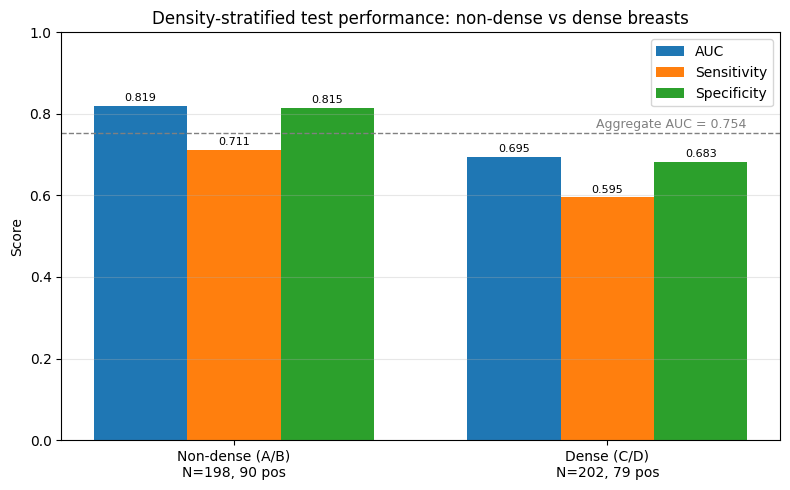

Saved -> /content/drive/MyDrive/MammoLens/results/fig_density_stratified.png


In [6]:
# Drawn from the saved metrics rather than typed in, so the figure cannot
# drift from the table it illustrates.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.join(cfg.paths.drive_root, 'initial_run', 'results')
m = pd.read_csv(os.path.join(RESULTS_DIR, 'test_metrics.csv'))

# Pull the two density-group rows and the aggregate.
agg = m[m['level'] == 'aggregate'].iloc[0]
grp = m[m['level'] == 'group'].set_index('stratum')

order = ['non-dense (A/B)', 'dense (C/D)']          # must match the keys in metrics['per_density_group']
labels = [f"Non-dense (A/B)\nN={int(grp.loc['non-dense (A/B)','n'])}, "
          f"{int(grp.loc['non-dense (A/B)','n_pos'])} pos",
          f"Dense (C/D)\nN={int(grp.loc['dense (C/D)','n'])}, "
          f"{int(grp.loc['dense (C/D)','n_pos'])} pos"]

auc  = [grp.loc[g, 'auc']         for g in order]
sens = [grp.loc[g, 'sensitivity'] for g in order]
spec = [grp.loc[g, 'specificity'] for g in order]
agg_auc = float(agg['auc'])

x = np.arange(len(order))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w, auc,  w, label='AUC')
b2 = ax.bar(x,      sens, w, label='Sensitivity')
b3 = ax.bar(x + w, spec, w, label='Specificity')

ax.axhline(agg_auc, color='gray', linestyle='--', linewidth=1)
ax.text(0.97, agg_auc + 0.012, f'Aggregate AUC = {agg_auc:.3f}',
        fontsize=9, color='gray', ha='left')

for bars in (b1, b2, b3):
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Density-stratified test performance: non-dense vs dense breasts')
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
out = os.path.join(RESULTS_DIR, 'fig_density_stratified.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', out)

<a id="f1"></a>
**Figure 1.** Test-set AUC, sensitivity and specificity for non-dense (BI-RADS A/B) and dense (BI-RADS C/D) breasts, from `best_model.pt`, with each group's image and malignant counts under its label. The dashed line marks the aggregate test AUC. Values are read from `initial_run/results/test_metrics.csv` and match Table 8.

Figure 1 shows the same numbers as the middle block of Table 5 and adds no new result. What it adds is a clear view of the pattern: the non-dense AUC (0.819) sits above the aggregate line and the dense AUC (0.695) below it, and every dense-group bar is shorter than its non-dense counterpart. The vertical axis starts at zero, so the bar heights are proportional to the scores and I am not exaggerating the gap with a truncated axis. There are no error bars because I computed no intervals at this stage, and the caveats in Section 5.3 apply to the figure unchanged.

<a id="s5-6"></a>
### 5.6 Supplementary checks

I added Sections 5.6 and 5.7 after the original run, to answer questions that Sections 3 to 5 had left hanging. How well does the model separate the classes on its own training data? Exactly which hyperparameters and cleaning steps produced this model and this dataset? How much does storage location really affect loading time? And how much statistical weight can my density gap actually bear? Nothing is retrained. Every check uses `best_model.pt` and the manifests frozen in Section 3.1, and nothing re-splits the data.

The cells are self-contained apart from one dependency: after a fresh Colab connection, run the Section 1.1 cell first because it installs the packages in `requirements.txt` (timm included), then run Sections 5.6 and 5.7 in order without rerunning Sections 1.2 to 6. The setup cell below mounts Drive if it needs to, reloads `configs/config.yaml` into a new object (`scfg`) rather than reusing `cfg`, which Section 3.3 modified, reads the three frozen manifests and defines a small `record` helper. Every numeric result in Sections 5.6 and 5.7 passes through that helper, and Section 5.7.5 writes them all to `initial_run/results/stat_tests.csv`, so the saved file and the printed outputs hold the same values. Outside Colab, the cell re-roots the Colab paths in the configuration to the local project folder.

In [1]:
# Section 5.6 setup: self-contained, so Sections 5.6 and 5.7 can run after a
# fresh Colab connect without re-running earlier sections. Nothing is retrained.
import os, sys, time, shutil, tempfile, copy
import numpy as np
import pandas as pd
import torch

IN_COLAB = 'google.colab' in sys.modules
COLAB_ROOT = '/content/drive/MyDrive/MammoLens'
if IN_COLAB:
    if not os.path.isdir('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
    PROJECT_DIR = COLAB_ROOT
else:  # local Jupyter: the notebook lives in <project>/notebooks
    here = os.getcwd()
    PROJECT_DIR = os.path.dirname(here) if os.path.basename(here) == 'notebooks' else here
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

from src.config import load_config
scfg = load_config('configs/config.yaml')      # fresh copy; Section 3.3 mutates `cfg`
if not IN_COLAB:                                # re-root the Colab paths locally
    for k, v in vars(scfg.paths).items():
        setattr(scfg.paths, k, v.replace(COLAB_ROOT, PROJECT_DIR))

DRIVE_DATA  = scfg.paths.data_dir               # manifests + images on Drive
LOCAL_DATA  = '/content/data' if IN_COLAB else os.path.join(tempfile.gettempdir(), 'mammolens_data')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'initial_run', 'results')
FIG_DIR     = os.path.join(PROJECT_DIR, 'initial_run', 'figures')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
SEED   = scfg.project.seed
POS    = scfg.evaluate.positive_class
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Frozen manifests from Section 3.1; nothing below re-splits the data.
MANIFESTS = {s: pd.read_csv(os.path.join(DRIVE_DATA, f'{s}.csv')) for s in ('train', 'val', 'test')}

# Every new numeric result goes through record(); Section 5.7.5 writes them
# to results/stat_tests.csv. Keyed, so re-running a cell overwrites its rows.
STATS = {}
def record(section, analysis, stratum, metric, value, ci_low=np.nan, ci_high=np.nan, note=''):
    STATS[(section, analysis, stratum, metric)] = dict(
        section=section, analysis=analysis, stratum=stratum, metric=metric,
        value=value, ci_low=ci_low, ci_high=ci_high, note=note)

print('Environment:', 'Colab' if IN_COLAB else 'local Jupyter')
print('Device     :', device, f'({torch.cuda.get_device_name(0)})' if device.type == 'cuda' else '')
print('Manifests  :', {s: len(d) for s, d in MANIFESTS.items()})

Environment: local Jupyter
Device     : cpu 
Manifests  : {'train': 2052, 'val': 405, 'test': 400}


The three frozen manifests load with 2052, 405 and 400 rows, the counts from Table 2, so everything below works on the split from Section 3.1. The environment and device lines record where the cell was last run. The outputs of Sections 5.6.3 and 5.6.4 depend only on the configuration, the code and the CSV files, so they come out the same wherever they run; the other cells need the images and, for any reasonable speed, the Colab GPU.

<a id="s5-6-1"></a>
#### 5.6.1 Per-image predictions

This cell produces the per-image predictions that the rest of Sections 5.6 and 5.7 depend on. In Colab it first makes sure every manifest image has a local copy, as in Section 3.3, because scoring 2857 images through the Drive mount would be painfully slow. Then it rebuilds EfficientNet-B0 from the configuration, loads the weights in `best_model.pt` and puts the network in evaluation mode, which fixes the batch normalisation statistics and switches dropout off. Every image in the test, training and validation manifests goes through the evaluation transform only, a resize to 224 by 224 pixels and ImageNet normalisation with no flip or rotation, and I keep the softmax probability of the malignant class.

I score the training split with the evaluation transform on purpose. The loader I use in training applies random augmentation and drops the last partial batch, so reusing it would give me a training AUC measured on altered images with some images missing, which I could not fairly set beside the validation and test AUCs. I score the validation split too, even though nothing asked for it on its own, because Section 5.6.2 needs it and Section 5.7.3 uses it to set a threshold that is not fitted on the test set.

Each output file (`initial_run/results/test_predictions.csv`, `initial_run/results/train_predictions.csv` and `initial_run/results/val_predictions.csv`) has one row per image, with `image_id` (the SeriesInstanceUID folder name, unique for each of the 2857 manifest images), `patient_id`, the true `label`, `prob_malignant`, `density` and the relative `image_path`. The cell ends with three checks against Section 5: the test file must hold 400 rows with 169 malignant images, the AUC recomputed from it must round to 0.754, and its confusion matrix at a threshold of 0.5 must equal Table 4. A 0.5 threshold on the malignant probability makes the same decision as the arg-max rule in `src/evaluate.py`. Inference runs in full 32-bit precision, as in Section 5, so the recomputed validation AUC may differ at the fourth decimal place from the value stored during training under mixed precision.

In [ ]:
# 5.6.1 Per-image predictions from best_model.pt on the frozen splits (eval mode, no augmentation).
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, confusion_matrix
from src.data import build_transforms
from src.model import build_model

# Local copy of every manifest image (as in Section 3.3), created if this session lacks it.
if IN_COLAB:
    from concurrent.futures import ThreadPoolExecutor
    rels = pd.concat([d['image_path'] for d in MANIFESTS.values()]).unique()
    def _copy(rel):
        dst = os.path.join(LOCAL_DATA, rel)
        if os.path.isfile(dst):
            return 0
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy(os.path.join(DRIVE_DATA, rel), dst)
        return 1
    with ThreadPoolExecutor(max_workers=8) as ex:
        N_COPIED_561 = sum(ex.map(_copy, rels))
    print(f'Local copy: {N_COPIED_561} copied this session, {len(rels) - N_COPIED_561} already present')
IMG_ROOT = LOCAL_DATA if IN_COLAB else DRIVE_DATA

class EvalImages(Dataset):
    # Evaluation transform for every split, including train (no flip, no rotation).
    def __init__(self, df, root, image_size):
        self.paths = df['image_path'].tolist()
        self.root = root
        self.tf = build_transforms(image_size, train=False)
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        with Image.open(os.path.join(self.root, self.paths[i])) as im:
            return self.tf(im.convert('RGB'))

mcfg = copy.deepcopy(scfg)
mcfg.model.pretrained = False          # weights come from the checkpoint; skip the ImageNet download
ckpt = torch.load(os.path.join(scfg.paths.checkpoint_dir, 'best_model.pt'),
                  map_location=device, weights_only=False)
net = build_model(mcfg).to(device)
net.load_state_dict(ckpt['model_state'])
net.eval()
print(f"Loaded best_model.pt (epoch {ckpt['epoch'] + 1}, stored val_auc {ckpt['best_auc']:.4f})")

@torch.no_grad()
def predict(df):
    loader = DataLoader(EvalImages(df, IMG_ROOT, scfg.data.image_size), batch_size=64,
                        shuffle=False, num_workers=scfg.data.num_workers)
    out = [torch.softmax(net(x.to(device)).float(), dim=1)[:, POS].cpu().numpy() for x in loader]
    return np.concatenate(out)

PRED = {}
for split in ('test', 'train', 'val'):
    d = MANIFESTS[split]
    t0 = time.time()
    PRED[split] = pd.DataFrame({
        'image_id':       d['image_path'].str.split('/').str[1],   # SeriesInstanceUID folder
        'patient_id':     d['patient_id'],
        'label':          d['label'].astype(int),
        'prob_malignant': predict(d),
        'density':        d['density'].astype(int),
        'image_path':     d['image_path'],
    })
    PRED[split].to_csv(os.path.join(RESULTS_DIR, f'{split}_predictions.csv'), index=False)
    print(f'{split:<5} {len(d):5d} images scored in {time.time() - t0:5.0f} s -> results/{split}_predictions.csv')

# Checks against Table 4.
te = PRED['test']
auc_te = roc_auc_score(te['label'], te['prob_malignant'])
tn, fp, fn, tp = confusion_matrix(te['label'], (te['prob_malignant'] >= 0.5).astype(int), labels=[0, 1]).ravel()
n_mal = int(te['label'].sum())
print(f'\nTest rows: {len(te)} (expected 400) | malignant: {n_mal} (expected 169)')
print(f'Recomputed test AUC: {auc_te:.4f} (rounds to {auc_te:.3f}; Table 4: 0.754) -> '
      f'{"MATCH" if round(auc_te, 3) == 0.754 else "MISMATCH"}')
print(f'Confusion at 0.5: TN {tn} FP {fp} FN {fn} TP {tp} (Table 4: TN 172 FP 59 FN 58 TP 111) -> '
      f'{"MATCH" if (tn, fp, fn, tp) == (172, 59, 58, 111) else "MISMATCH"}')
assert len(te) == 400 and n_mal == 169, 'test manifest does not match Section 3.1'
record('5.6.1', 'prediction check', 'test', 'rows', len(te))
record('5.6.1', 'prediction check', 'test', 'malignant', n_mal)
record('5.6.1', 'prediction check', 'test', 'AUC recomputed', auc_te)
for k, v in dict(tn=tn, fp=fp, fn=fn, tp=tp).items():
    record('5.6.1', 'prediction check', 'test', f'{k.upper()} at 0.5', int(v))

> **Interpretation pending.** I have not run this cell yet. It needs the images and a GPU, and I had neither when I wrote this section. Once Sections 5.6 and 5.7 have been run in Colab, this cell gets replaced with what the output actually shows.

<a id="s5-6-2"></a>
#### 5.6.2 Discrimination on training, validation and test data

Comparing AUC across the three splits is the most direct check for overfitting I can make. A model that has memorised its training images ranks them almost perfectly and ranks unseen images much less well, so a training AUC far above validation and test is the signature to look for. The cell computes AUC from the saved probabilities for each split and prints it to four decimal places with the image and malignant counts, then the training minus validation difference. It also prints the validation AUC stored in the checkpoint next to the recomputed one, to check my predictions reproduce the figure I used for model selection.

In [ ]:
# 5.6.2 AUC on train / val / test from the per-image predictions.
AUC_SPLIT = {}
rows = []
for split in ('train', 'val', 'test'):
    p = PRED[split]
    AUC_SPLIT[split] = roc_auc_score(p['label'], p['prob_malignant'])
    rows.append({'split': split, 'N': len(p), 'malignant': int(p['label'].sum()), 'AUC': AUC_SPLIT[split]})
    record('5.6.2', 'discrimination by split', split, 'AUC', AUC_SPLIT[split])
print(pd.DataFrame(rows).to_string(index=False, formatters={'AUC': '{:.4f}'.format}))

gap_tv = AUC_SPLIT['train'] - AUC_SPLIT['val']
record('5.6.2', 'discrimination by split', 'train minus val', 'AUC difference', gap_tv)
print(f"\nTrain minus validation AUC: {gap_tv:+.4f}")
print(f"Validation AUC stored in checkpoint: {ckpt['best_auc']:.4f} | recomputed here: {AUC_SPLIT['val']:.4f}")

<a id="ts1"></a>
**Table S1.** AUC of `best_model.pt` on the training, validation and test splits, computed from the per-image predictions of Section 5.6.1 with the evaluation transform (no augmentation) for every split.

> **Interpretation pending.** I have not run this cell yet. It needs the images and a GPU, and I had neither when I wrote this section. Once Sections 5.6 and 5.7 have been run in Colab, this cell gets replaced with what the output actually shows.

<a id="s5-6-3"></a>
#### 5.6.3 Hyperparameters

Section 4.1 named several training settings without giving their values, because no cell had printed them. This cell prints every setting with its value and where the value comes from. Most of them come from `configs/config.yaml`. The ones fixed in code rather than in the configuration I read from the code objects themselves: the optimiser and the loss are built with the same helper functions `src/train.py` uses, and the augmentation entry is the actual transform pipeline `src.data.build_transforms` returns. Reading the values from the objects instead of retyping them means the table cannot drift away from the code.

That is not quite the same as describing the training run, because I could have edited the files after training. So the cell also prints the last-modified times of the configuration, the three source files involved in training, and `best_model.pt`.

In [2]:
# 5.6.3 Every training setting with its value and source.
from datetime import datetime, timezone
from src.data import build_transforms
from src.train import _make_optimizer, _make_criterion

opt  = _make_optimizer(scfg, torch.nn.Linear(1, 1))   # same helper as training, on a dummy module
crit = _make_criterion(scfg, None, 'cpu')              # class weights off, so no loader is needed
tfs  = build_transforms(scfg.data.image_size, train=True).transforms
aug  = [repr(t) for t in tfs if type(t).__name__.startswith('Random')]
t, m = scfg.train, scfg.model
hp = pd.DataFrame([
    ('Optimiser',                      type(opt).__name__,                'config.yaml train.optimizer, via src/train.py'),
    ('Learning rate',                  t.learning_rate,                   'config.yaml'),
    ('Weight decay',                   t.weight_decay,                    'config.yaml'),
    ('Learning-rate schedule',         f'{t.scheduler}: CosineAnnealingLR, T_max = {t.epochs}, stepped once per epoch',
                                                                          'config.yaml + src/train.py'),
    ('Epochs',                         t.epochs,                          'config.yaml'),
    ('Batch size',                     t.batch_size,                      'config.yaml'),
    ('Dropout before classifier',      m.drop_rate,                       'config.yaml'),
    ('Mixed precision (AMP)',          f'{t.mixed_precision} (applied on CUDA only)', 'config.yaml + src/train.py'),
    ('Early stopping patience',        f'{t.early_stopping_patience} epochs', 'config.yaml'),
    ('Early stopping monitor',         'validation AUC; best_model.pt saved on improvement', 'src/train.py'),
    ('Loss',                           type(crit).__name__,               'src/train.py'),
    ('Class weighting',                t.use_class_weights,               'config.yaml'),
    ('Augmentation (train only)',      ' + '.join(aug),                   'src/data.py'),
    ('Image size',                     f'{scfg.data.image_size} x {scfg.data.image_size} (aspect ratio not kept)', 'config.yaml + src/data.py'),
    ('Normalisation',                  'ImageNet mean and standard deviation', 'src/data.py'),
    ('Backbone',                       f'{m.name}, ImageNet-pretrained = {m.pretrained}, classes = {m.num_classes}', 'config.yaml'),
    ('Seed',                           scfg.project.seed,                 'config.yaml'),
], columns=['Setting', 'Value', 'Source'])
with pd.option_context('display.max_colwidth', 120):
    print(hp.to_string(index=False))

print('\nLast modified (UTC):')
for f in ('configs/config.yaml', 'src/train.py', 'src/data.py', 'src/model.py',
          os.path.relpath(os.path.join(scfg.paths.checkpoint_dir, 'best_model.pt'), PROJECT_DIR)):
    ts = datetime.fromtimestamp(os.path.getmtime(os.path.join(PROJECT_DIR, f)), timezone.utc)
    print(f'  {f:<28} {ts:%Y-%m-%d %H:%M}')

C:\Users\Zozozang\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                  Setting                                                                                                            Value                                        Source
                Optimiser                                                                                                            AdamW config.yaml train.optimizer, via src/train.py
            Learning rate                                                                                                           0.0003                                   config.yaml
             Weight decay                                                                                                           0.0001                                   config.yaml
   Learning-rate schedule                                                    cosine: CosineAnnealingLR, T_max = 12, stepped once per epoch                    config.yaml + src/train.py
                   Epochs                                                  

<a id="ts2"></a>
**Table S2.** Training settings for the v1 `best_model.pt`, with the source of each value. Values marked `src/...` are read from the code objects rather than retyped. The list after the table gives the last-modified time of each file involved.

Table S2 fills in the values Section 4.1 could only name. Training used AdamW with a learning rate of 0.0003 and weight decay of 0.0001, a cosine schedule over the 12 epochs, a batch size of 32, dropout of 0.3 before the classifier, mixed precision on the GPU and unweighted cross-entropy loss. Early stopping would have ended training after 5 epochs without an improvement in validation AUC, and Section 4.1 established that it never triggered. The only augmentation was a random horizontal flip at probability 0.5 and a random rotation of up to 10 degrees either way, with the corners rotated in from outside the image filled with black (`fill=0`). None of it departs from what I described in Section 4.1.

The modification times qualify the table, and I would rather point this out myself. `configs/config.yaml`, `src/data.py` and `src/model.py` were all last changed before `best_model.pt` was written, so the configured values, the augmentation and the model definition shown here were in force when the checkpoint was saved. `src/train.py` was modified about an hour after the checkpoint. The entries that come from that file, meaning how the optimiser is built, the step pattern of the schedule, the loss, the early stopping monitor and where mixed precision applies, therefore describe the current code, and this notebook cannot show whether the later edit changed any of them. The times are file-system timestamps as synced by Google Drive: they tell me when a file was last written, not what changed in it.

<a id="s5-6-4"></a>
#### 5.6.4 Data cleaning counts

Section 3.1 printed only the end result of cleaning, 2857 images from 1460 patients, which left me unable to say what I had dropped. This cell repeats the metadata linkage and cleaning from Section 3.1 on the CSV files alone, with no images loaded and no model involved, and prints the row count after each step: the raw abnormality rows in the four case files, the rows whose DICOM path resolves to a full-mammogram JPEG, the rows whose JPEG exists on disk, the rows with a valid BI-RADS density of 1 to 4, and finally the unique images and patients. The code is my Section 3.1 code with the steps pulled apart. Section 3.1 applied the density filter before the file check, which does not change the final set, and the cell asserts that the result matches my frozen manifests exactly. The file check tests that the file exists, as Section 3.1 did, without decoding it; Section 5.6.1 decodes every manifest image during inference anyway.

The second part answers something Section 3.1 left open. Several abnormality rows can describe the same image, and Section 3.1 kept the density of the first one. The cell counts how many images have more than one row, how many of those have rows that disagree on density, and how many of those disagreements cross the A/B against C/D boundary I use in Section 5. It also counts images whose rows disagree on pathology, which the any-malignant rule resolves by design.

In [3]:
# 5.6.4 Re-run ONLY the metadata linkage and cleaning from Section 3.1, counting rows per step.
CSV_DIR = os.path.join(DRIVE_DATA, 'csv')
dicom = pd.read_csv(os.path.join(CSV_DIR, 'dicom_info.csv'))
full = dicom[dicom['SeriesDescription'] == 'full mammogram images'].copy()
full['rel'] = full['image_path'].str.replace(r'^CBIS-DDSM/', '', regex=True)
uid2path = dict(zip(full['SeriesInstanceUID'].astype(str), full['rel']))

def resolve_jpeg(image_file_path):
    for part in str(image_file_path).strip().split('/'):
        if part in uid2path:
            return uid2path[part]
    return None

frames = []
for fname in ['mass_case_description_train_set.csv', 'mass_case_description_test_set.csv',
              'calc_case_description_train_set.csv', 'calc_case_description_test_set.csv']:
    df = pd.read_csv(os.path.join(CSV_DIR, fname))
    dens_col = next(c for c in df.columns if 'density' in c.lower())
    path_col = next(c for c in df.columns if c.lower() == 'image file path')
    frames.append(pd.DataFrame({
        'patient_id': df['patient_id'],
        'label':      (df['pathology'].str.upper() == 'MALIGNANT').astype(int),
        'density':    pd.to_numeric(df[dens_col], errors='coerce'),
        'image_path': df[path_col].map(resolve_jpeg),
    }))

s0 = pd.concat(frames, ignore_index=True)
s1 = s0.dropna(subset=['image_path'])
s2 = s1[s1['image_path'].map(lambda p: os.path.isfile(os.path.join(DRIVE_DATA, p)))]
s3 = s2[s2['density'].between(1, 4) & (s2['density'] % 1 == 0)]   # NaN fails between()
s4 = (s3.groupby('image_path', as_index=False)
        .agg(label=('label', 'max'), density=('density', 'first'), patient_id=('patient_id', 'first')))

steps = [('raw abnormality rows (4 case CSVs)', len(s0)),
         ('after path resolution (UID found among full mammograms)', len(s1)),
         ('after removing paths with no file on disk', len(s2)),
         ('after removing missing or invalid density (not 1 to 4)', len(s3)),
         ('after deduplication to unique images', len(s4))]
prev = None
print(f"{'step':<58}{'rows':>6}{'removed':>9}")
for name, n in steps:
    print(f"{name:<58}{n:>6}{'' if prev is None else prev - n:>9}")
    record('5.6.4', 'cleaning counts', 'all', name, n)
    prev = n
n_pat = s4['patient_id'].nunique()
print(f"{'patients':<58}{n_pat:>6}")
record('5.6.4', 'cleaning counts', 'all', 'patients', n_pat)

# Why did rows fail path resolution? Look their UIDs up among ALL dicom_info series.
uid2desc = dict(zip(dicom['SeriesInstanceUID'].astype(str), dicom['SeriesDescription']))
def uid_type(image_file_path):
    for part in str(image_file_path).strip().split('/'):
        if part in uid2desc:
            d = uid2desc[part]
            return d if isinstance(d, str) else 'in dicom_info, SeriesDescription blank'
    return 'UID not in dicom_info'
raw_paths = pd.concat([pd.read_csv(os.path.join(CSV_DIR, f))[['image file path']] for f in
                       ['mass_case_description_train_set.csv', 'mass_case_description_test_set.csv',
                        'calc_case_description_train_set.csv', 'calc_case_description_test_set.csv']],
                      ignore_index=True)
unres = raw_paths.loc[s0.index.difference(s1.index), 'image file path'].map(uid_type).value_counts()
print('\nUnresolved rows by what their UID matches in dicom_info:')
for k, v in unres.items():
    print(f'  {k:<40}{v:>5}')
    record('5.6.4', 'unresolved rows by UID match', 'all', k, int(v))
# What are the blank-description series? Compare their pixel dimensions with the labelled types.
blank_uids = {part for p in raw_paths.loc[s0.index.difference(s1.index), 'image file path']
              for part in str(p).strip().split('/')
              if part in uid2desc and not isinstance(uid2desc[part], str)}
blk = dicom[dicom['SeriesInstanceUID'].astype(str).isin(blank_uids)]
print(f'\nMedian pixel size (rows x columns) by series type in dicom_info:')
for name, d in (('full mammogram images', dicom[dicom['SeriesDescription'] == 'full mammogram images']),
                ('cropped images', dicom[dicom['SeriesDescription'] == 'cropped images']),
                ('ROI mask images', dicom[dicom['SeriesDescription'] == 'ROI mask images']),
                ('blank, referenced by unresolved rows', blk)):
    print(f"  {name:<40}{int(d['Rows'].median()):>6} x {int(d['Columns'].median()):<6} ({len(d)} images)")
n_blk_on_disk = int(blk['image_path'].str.replace(r'^CBIS-DDSM/', '', regex=True)
                    .map(lambda p: os.path.isfile(os.path.join(DRIVE_DATA, p))).sum())
print(f'  JPEGs of those blank-description images present on disk: {n_blk_on_disk} of {len(blk)}')
record('5.6.4', 'unresolved rows by UID match', 'all', 'blank-description images referenced', len(blk))
record('5.6.4', 'unresolved rows by UID match', 'all', 'blank-description JPEGs on disk', n_blk_on_disk)
lost_pat = s0['patient_id'].nunique() - n_pat
print(f"Patients in raw rows: {s0['patient_id'].nunique()} | lost entirely by cleaning: {lost_pat}")
record('5.6.4', 'cleaning counts', 'all', 'patients in raw rows', s0['patient_id'].nunique())
record('5.6.4', 'cleaning counts', 'all', 'patients lost entirely', lost_pat)

frozen = set(pd.concat([d['image_path'] for d in MANIFESTS.values()]))
assert set(s4['image_path']) == frozen and n_pat == 1460, 'does not reproduce the Section 3.1 manifests'
print('\nOK: the cleaned set equals the union of the frozen train/val/test manifests.')

# Rows describing the same image: do they agree?
g = s3.groupby('image_path')
per_img = pd.DataFrame({'rows': g.size(), 'n_density': g['density'].nunique(),
                        'n_label': g['label'].nunique(), 'n_patient': g['patient_id'].nunique(),
                        'grp_min': g['density'].min().isin([1, 2]), 'grp_max': g['density'].max().isin([1, 2])})
multi = int((per_img['rows'] > 1).sum())
dens_dis = per_img[per_img['n_density'] > 1]
cross = int((dens_dis['grp_min'] != dens_dis['grp_max']).sum())
lab_dis = int((per_img['n_label'] > 1).sum())
pat_dis = int((per_img['n_patient'] > 1).sum())
print(f'\nImages with more than one abnormality row:        {multi}')
print(f'  ...whose rows disagree on density:               {len(dens_dis)}')
print(f'  ...of which cross the A/B vs C/D boundary:       {cross}')
print(f'  ...whose rows disagree on pathology label:       {lab_dis}')
print(f'  ...whose rows disagree on patient_id:            {pat_dis}')
for metric, v in [('images with >1 row', multi), ('density disagreement', len(dens_dis)),
                  ('density disagreement crossing A/B vs C/D', cross),
                  ('label disagreement', lab_dis), ('patient_id disagreement', pat_dis)]:
    record('5.6.4', 'row agreement per image', 'all', metric, v)
if len(dens_dis):
    where = {s: int(d['image_path'].isin(dens_dis.index).sum()) for s, d in MANIFESTS.items()}
    print('  density-disagreement images per split:', where)

step                                                        rows  removed
raw abnormality rows (4 case CSVs)                          3568         
after path resolution (UID found among full mammograms)     3286      282
after removing paths with no file on disk                   3286        0
after removing missing or invalid density (not 1 to 4)      3286        0
after deduplication to unique images                        2857      429
patients                                                    1460



Unresolved rows by what their UID matches in dicom_info:
  in dicom_info, SeriesDescription blank    282

Median pixel size (rows x columns) by series type in dicom_info:
  full mammogram images                     5236 x 3016   (2857 images)
  cropped images                             337 x 340    (3567 images)
  ROI mask images                           5116 x 3040   (3247 images)
  blank, referenced by unresolved rows      5123 x 2952   (246 images)


  JPEGs of those blank-description images present on disk: 246 of 246
Patients in raw rows: 1566 | lost entirely by cleaning: 106

OK: the cleaned set equals the union of the frozen train/val/test manifests.

Images with more than one abnormality row:        258
  ...whose rows disagree on density:               0
  ...of which cross the A/B vs C/D boundary:       0
  ...whose rows disagree on pathology label:       15
  ...whose rows disagree on patient_id:            0


<a id="ts3"></a>
**Table S3.** Row counts after each metadata linkage and cleaning step of Section 3.1, reproduced from the CSV files alone, followed by counts of images whose abnormality rows disagree.

Table S3 accounts for every row between the raw metadata and my final dataset, and it turned up something I had not expected. The four case files hold 3568 abnormality rows. Path resolution removes 282 of them, and the next two filters remove nothing at all: every resolved JPEG exists on disk, and every remaining row has a valid density. Deduplication then merges 429 rows into images that already had one, leaving 2857 unique images from 1460 patients. The cell reproduces my frozen manifests exactly.

The 282 rows lost at path resolution matter far more than their number suggests. Their UIDs are present in `dicom_info.csv`, but with a blank `SeriesDescription`, so my Section 3.1 filter, which keeps only series labelled `full mammogram images`, threw them away. They point to 246 distinct images, and all of them are on disk. The median size of those images, 5123 by 2952 pixels, is close to the full mammograms' 5236 by 3016 and nothing like the cropped images' 337 by 340. Size alone cannot rule out ROI masks, which are also full-size, but these UIDs come from the case files' `image file path` column, which is the column that points at the full mammogram. The most likely reading is that they are full mammograms whose series label is missing from the metadata. If that is right, my cleaning threw out 246 usable images because of a gap in the metadata rather than anything wrong with the images, and 106 of the 1566 patients in the raw files were lost outright. This notebook does not open those images to confirm what they are, and it does not check whether the excluded cases differ in label or density. I went back and recovered them in `MammoLens_recovered_data_rebuild.ipynb`, which accepted all 246 and grew the dataset to 3085 images from 1565 patients, and the model retrained on them tested worse rather than better, so this exclusion was not what was holding my model back.

The other question, about density, can be closed. Of the 258 images described by more than one abnormality row, not one has rows that disagree on density, so taking the first row's density changed nothing. Fifteen images have rows that disagree on pathology, and the any-malignant rule labels all 15 malignant, which is what I intended. No image has rows from different patients.

<a id="s5-6-5"></a>
#### 5.6.5 Storage timing

My code comment in Section 3.3 claims that reading images through the Drive mount made training slow and that a local copy fixed it, and no output anywhere supported the figures it quoted. This cell measures it. I draw 200 training images with a fixed seed, make sure each has a local copy, copying any that are missing, and time loading all 200 first from the Drive-mounted path and then from the local copy. By loading I mean what the data loader does to each image before it reaches the GPU: opening the JPEG, decoding it, converting it to three channels, resizing and normalising. The cell prints seconds per image and a projected time per epoch, worked out by multiplying by the number of images one training epoch processes, which is the training-set size rounded down to whole batches because the last partial batch is dropped.

Two limits apply. The loading here runs in a single process, whereas training used two loader workers, so my projection is a single-process figure rather than a forecast of wall-clock epoch time. And any image already read through the mount in this session, including by the copy step in Section 5.6.1, may be served from Colab's Drive cache, which would make the Drive figure look better than a cold read.

In [ ]:
# 5.6.5 Time loading 200 training images from the Drive mount versus the local session copy.
from PIL import Image
from src.data import build_transforms

N_TIME = 200
rng_t = np.random.default_rng(SEED)
tr_paths = MANIFESTS['train']['image_path'].to_numpy()
sample = tr_paths[rng_t.choice(len(tr_paths), N_TIME, replace=False)]

made = 0                                   # create the local copy first where missing
for rel in sample:
    dst = os.path.join(LOCAL_DATA, rel)
    if not os.path.isfile(dst):
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy(os.path.join(DRIVE_DATA, rel), dst)
        made += 1
print(f'Local copy for the timing sample: {made} copied now, {N_TIME - made} already present')

tf_eval = build_transforms(scfg.data.image_size, train=False)
def time_load(root):
    t0 = time.perf_counter()
    for rel in sample:
        with Image.open(os.path.join(root, rel)) as im:
            tf_eval(im.convert('RGB'))
    return time.perf_counter() - t0

IMGS_PER_EPOCH = (len(tr_paths) // scfg.train.batch_size) * scfg.train.batch_size   # drop_last=True
rows = []
for name, root in (('Drive-mounted path', DRIVE_DATA), ('local session copy', LOCAL_DATA)):
    total = time_load(root)
    per = total / N_TIME
    rows.append({'source': name, 'path': root, 'total s (200 images)': round(total, 2),
                 's per image': round(per, 4), 'projected s per epoch': round(per * IMGS_PER_EPOCH, 1)})
    record('5.6.5', 'storage timing', name, 's per image', per, note=root)
    record('5.6.5', 'storage timing', name, 'projected s per epoch (single process)', per * IMGS_PER_EPOCH,
           note=f'{IMGS_PER_EPOCH} images per epoch')
print(f'Images per training epoch: {IMGS_PER_EPOCH} ({len(tr_paths)} rounded down to whole batches of {scfg.train.batch_size})\n')
print(pd.DataFrame(rows).to_string(index=False))

<a id="ts4"></a>
**Table S4.** Time to load (open, decode, resize and normalise) the same 200 training images from the Drive-mounted path and from the local session copy, single process, with the projected time per training epoch.

> **Interpretation pending.** I have not run this cell yet. It needs the images and a GPU, and I had neither when I wrote this section. Once Sections 5.6 and 5.7 have been run in Colab, this cell gets replaced with what the output actually shows.

<a id="s5-7"></a>
### 5.7 Statistical analysis of the density gap

Section 5.3 found lower performance in dense breasts but could not say how much of that gap might be sampling noise, which is the obvious question anyone reading it would ask. This section answers it from `initial_run/results/test_predictions.csv`, written in Section 5.6.1, without running the model again. The non-dense and dense groups hold different patients, which the first cell checks, so I treat them as independent samples throughout.

<a id="s5-7-1"></a>
#### 5.7.1 Bootstrap confidence intervals

The bootstrap (Efron and Tibshirani, 1993) estimates how much a statistic varies from sample to sample by recomputing it on many resamples drawn with replacement from the data I have. I draw 2000 resamples with a fixed seed, and in each one the non-dense and dense groups are resampled separately, each keeping its own size. The aggregate row joins the two resampled groups, so every resample holds exactly as many non-dense and dense images as my real test set. For each resample the cell computes AUC and, at a threshold of 0.5, sensitivity and specificity. The 95% interval runs from the 2.5th to the 97.5th percentile of those values, which is the percentile method. The point estimates come from the full test set and should reproduce Table 4.

I chose percentile intervals over normal-approximation ones because sensitivity and specificity are proportions and their sampling distributions can be skewed. Images are resampled individually, as the plan specified. Most of my patients contribute more than one image, as the printed patient counts show, so the images are not fully independent and resampling them one at a time tends to understate the uncertainty. Section 5.7.2 repeats the key comparison with patients as the resampling unit to show how much that matters.

In [ ]:
# 5.7.1 Stratified bootstrap CIs (2000 resamples, fixed seed) for AUC, sensitivity, specificity.
from scipy.stats import norm
from sklearn.metrics import roc_auc_score

pred = pd.read_csv(os.path.join(RESULTS_DIR, 'test_predictions.csv'))
AB, CD = 'non-dense (A/B)', 'dense (C/D)'
pred['group'] = np.where(pred['density'].isin([1, 2]), AB, CD)
G = {AB: pred[pred['group'] == AB].reset_index(drop=True),
     CD: pred[pred['group'] == CD].reset_index(drop=True)}
shared = set(G[AB]['patient_id']) & set(G[CD]['patient_id'])
print(f"Test images {len(pred)} from {pred['patient_id'].nunique()} patients | "
      f"{AB}: {len(G[AB])} images, {G[AB]['patient_id'].nunique()} patients | "
      f"{CD}: {len(G[CD])} images, {G[CD]['patient_id'].nunique()} patients | "
      f"patients in both groups: {len(shared)}")
assert not shared, 'groups share patients; the independence assumption fails'

THR, N_BOOT = 0.5, 2000
def point_metrics(y, p, thr=THR):
    yhat = p >= thr
    tp = np.sum(yhat & (y == 1)); fn = np.sum(~yhat & (y == 1))
    tn = np.sum(~yhat & (y == 0)); fp = np.sum(yhat & (y == 0))
    return roc_auc_score(y, p), tp / (tp + fn), tn / (tn + fp)

yA, pA = G[AB]['label'].to_numpy(), G[AB]['prob_malignant'].to_numpy()
yC, pC = G[CD]['label'].to_numpy(), G[CD]['prob_malignant'].to_numpy()
POINT = {'all': point_metrics(np.r_[yA, yC], np.r_[pA, pC]), AB: point_metrics(yA, pA), CD: point_metrics(yC, pC)}

rng_b = np.random.default_rng(SEED)
BOOT = {k: [] for k in POINT}
n_skip = 0
for _ in range(N_BOOT):
    iA = rng_b.integers(0, len(yA), len(yA))
    iC = rng_b.integers(0, len(yC), len(yC))
    ya, pa, yc, pc = yA[iA], pA[iA], yC[iC], pC[iC]
    if min(ya.sum(), (1 - ya).sum(), yc.sum(), (1 - yc).sum()) == 0:
        n_skip += 1                        # AUC undefined with one class; never expected at these sizes
        continue
    BOOT[AB].append(point_metrics(ya, pa))
    BOOT[CD].append(point_metrics(yc, pc))
    BOOT['all'].append(point_metrics(np.r_[ya, yc], np.r_[pa, pc]))
BOOT = {k: np.array(v) for k, v in BOOT.items()}
print(f'Bootstrap: {N_BOOT} resamples, seed {SEED}, {n_skip} skipped for a single class\n')

rows = []
for k, d in (('all', pred), (AB, G[AB]), (CD, G[CD])):
    r = {'stratum': k, 'N': len(d), 'pos': int(d['label'].sum())}
    for j, name in enumerate(('AUC', 'sensitivity', 'specificity')):
        lo, hi = np.percentile(BOOT[k][:, j], [2.5, 97.5])
        r[name] = f'{POINT[k][j]:.3f} [{lo:.3f}, {hi:.3f}]'
        record('5.7.1', 'bootstrap 95% CI (image-level, within stratum)', k, name, POINT[k][j], lo, hi,
               note=f'{N_BOOT} resamples, seed {SEED}, threshold {THR}')
    rows.append(r)
print(pd.DataFrame(rows).to_string(index=False))

<a id="t6"></a>
**Table 6.** Test-set AUC, sensitivity and specificity (threshold 0.5), each as a point estimate with its 95% percentile bootstrap confidence interval, from 2000 resamples drawn separately within the non-dense (A/B) and dense (C/D) groups. Point estimates come from the full test set.

> **Interpretation pending.** I have not run this cell yet. It needs the images and a GPU, and I had neither when I wrote this section. Once Sections 5.6 and 5.7 have been run in Colab, this cell gets replaced with what the output actually shows.

<a id="s5-7-2"></a>
#### 5.7.2 Testing the density gap

What I actually want to know is the non-dense minus dense AUC difference, so the cell estimates its uncertainty three ways.

The first reuses the resamples from Section 5.7.1. Because I resampled the groups independently, the 2000 differences between their resampled AUCs form a bootstrap distribution for the gap, and its 2.5th and 97.5th percentiles give me a 95% interval. For the test, each group's standard error is the standard deviation of its bootstrap AUCs, z is the observed difference divided by the square root of the sum of the two squared standard errors, and the two-sided p-value comes from the standard normal distribution. This is my primary test.

The second swaps the bootstrap standard errors for the closed-form approximation of Hanley and McNeil (1982), which depends only on the AUC and the numbers of malignant and benign images. It is a check on the first. If the two disagree materially I report both and prefer the more conservative one, a rule I fixed before seeing any results.

The third repeats the bootstrap with patients rather than images as the resampling unit, again within each group, so that all of a resampled patient's images come along together (Field and Welsh, 2007). That respects the correlation between two views of the same breast. If it gives a noticeably wider interval than the image-level bootstrap, then the image-level result is overstating my precision.

DeLong's test (DeLong, DeLong and Clarke-Pearson, 1988) is the usual choice for comparing AUCs, and it does not fit what I am doing. It is a paired test, built for two AUCs measured on the same cases, such as two models or two readers scoring one test set, and its variance for the difference includes the covariance between the two AUCs, which exists because every case contributes to both. Here one model is scored on two disjoint groups of images from different patients. No case contributes to both AUCs, so there is nothing to pair and the covariance is zero by construction. With zero covariance the comparison reduces to a z-test on the difference using independent variances, which is the unpaired test I apply.

In [ ]:
# 5.7.2 Non-dense minus dense AUC: bootstrap CI and unpaired z-tests.
aucA, aucC = POINT[AB][0], POINT[CD][0]
diff = aucA - aucC

def z_test(d, se_a, se_c):
    z = d / np.hypot(se_a, se_c)
    return z, 2 * norm.sf(abs(z))

# (1) Image-level bootstrap (resamples from 5.7.1).
bA, bC = BOOT[AB][:, 0], BOOT[CD][:, 0]
ci_img = np.percentile(bA - bC, [2.5, 97.5])
se_img = (bA.std(ddof=1), bC.std(ddof=1))
z_img, p_img = z_test(diff, *se_img)

# (2) Hanley and McNeil (1982) standard errors.
def hanley_mcneil_se(auc, n_pos, n_neg):
    q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    return np.sqrt((auc * (1 - auc) + (n_pos - 1) * (q1 - auc ** 2) + (n_neg - 1) * (q2 - auc ** 2)) / (n_pos * n_neg))
se_hm = (hanley_mcneil_se(aucA, int(yA.sum()), int((1 - yA).sum())),
         hanley_mcneil_se(aucC, int(yC.sum()), int((1 - yC).sum())))
z_hm, p_hm = z_test(diff, *se_hm)
ci_hm = (diff - 1.96 * np.hypot(*se_hm), diff + 1.96 * np.hypot(*se_hm))

# (3) Patient-level (cluster) bootstrap within each group.
rng_c = np.random.default_rng(SEED)
def cluster_boot_auc(df, rng, n):
    idx = df.groupby('patient_id').indices               # patient -> row positions
    groups = list(idx.values())
    y, p = df['label'].to_numpy(), df['prob_malignant'].to_numpy()
    out = []
    while len(out) < n:
        pick = rng.integers(0, len(groups), len(groups))
        rows_ = np.concatenate([groups[i] for i in pick])
        if 0 < y[rows_].sum() < len(rows_):
            out.append(roc_auc_score(y[rows_], p[rows_]))
    return np.array(out)
cA, cC = cluster_boot_auc(G[AB], rng_c, N_BOOT), cluster_boot_auc(G[CD], rng_c, N_BOOT)
ci_pat = np.percentile(cA - cC, [2.5, 97.5])
se_pat = (cA.std(ddof=1), cC.std(ddof=1))
z_pat, p_pat = z_test(diff, *se_pat)

res = pd.DataFrame([
    ('image-level bootstrap (primary)', ci_img, se_img, z_img, p_img),
    ('Hanley-McNeil SE (normal CI)',    ci_hm,  se_hm,  z_hm,  p_hm),
    ('patient-level bootstrap',         ci_pat, se_pat, z_pat, p_pat),
], columns=['method', 'ci', 'se', 'z', 'p'])
print(f'AUC non-dense (A/B) = {aucA:.4f} | AUC dense (C/D) = {aucC:.4f} | difference = {diff:.4f}\n')
print(f"{'method':<34}{'95% CI of difference':>24}{'SE A/B':>9}{'SE C/D':>9}{'z':>8}{'p (two-sided)':>15}")
for _, r in res.iterrows():
    print(f"{r.method:<34}{f'[{r.ci[0]:.4f}, {r.ci[1]:.4f}]':>24}{r.se[0]:>9.4f}{r.se[1]:>9.4f}{r.z:>8.3f}{r.p:>15.4f}")
    for metric, v in (('SE A/B', r.se[0]), ('SE C/D', r.se[1]), ('z', r.z), ('p two-sided', r.p)):
        record('5.7.2', f'AUC gap: {r.method}', 'A/B minus C/D', metric, v)
    record('5.7.2', f'AUC gap: {r.method}', 'A/B minus C/D', 'difference', diff, r.ci[0], r.ci[1])
print(f"\nPrimary test: {'significant' if p_img < 0.05 else 'not significant'} at the 0.05 level (p = {p_img:.4f}).")

> **Interpretation pending.** I have not run this cell yet. It needs the images and a GPU, and I had neither when I wrote this section. Once Sections 5.6 and 5.7 have been run in Colab, this cell gets replaced with what the output actually shows.

<a id="s5-7-3"></a>
#### 5.7.3 Operating points at a specificity of 0.80

A threshold of 0.5 is arbitrary. A screening aid would more likely run at a fixed specificity, which caps the false-positive rate, and be judged on the sensitivity it reaches there. For each group, all images, non-dense and dense, the cell finds the lowest threshold on the malignant probability at which specificity is at least 0.80. Of all the thresholds that satisfy that constraint, this one gives the highest sensitivity. It reports the threshold, the specificity actually reached, since exactly 0.80 is not always attainable with a finite number of benign images, and the sensitivity. Setting a separate threshold per density group assumes density is known when the model is applied, which is reasonable because density is assessed as part of mammographic reporting (D'Orsi et al., 2013).

A threshold chosen on the test set is fitted to the test data, so the sensitivity it gives is flattering. The cell therefore reports a second version where each group's threshold is found on the validation predictions from Section 5.6.1 and applied unchanged to the test set. That is the fairer estimate of what a fixed operating point would deliver on images the model has not seen. Both versions appear in Table 7 and are saved to `initial_run/results/operating_points.csv`.

In [ ]:
# 5.7.3 Sensitivity at specificity >= 0.80, per stratum (test-fitted and validation-fitted thresholds).
TARGET_SPEC = 0.80

def threshold_at_spec(y, p, target=TARGET_SPEC):
    # Lowest threshold t (predict malignant if p >= t) with specificity >= target.
    neg = p[y == 0]
    for t in np.unique(np.r_[p, np.inf]):          # ascending
        if np.mean(neg < t) >= target:
            return t

def rates(y, p, t):
    yhat = p >= t
    tp = int(np.sum(yhat & (y == 1))); fn = int(np.sum(~yhat & (y == 1)))
    tn = int(np.sum(~yhat & (y == 0))); fp = int(np.sum(yhat & (y == 0)))
    return tn / (tn + fp), tp / (tp + fn), tp, fn, tn, fp

val = PRED['val'] if 'PRED' in globals() else pd.read_csv(os.path.join(RESULTS_DIR, 'val_predictions.csv'))
val = val.assign(group=np.where(val['density'].isin([1, 2]), AB, CD))
test_sets = {'all': pred, AB: G[AB], CD: G[CD]}
val_sets = {'all': val, AB: val[val['group'] == AB], CD: val[val['group'] == CD]}

rows = []
for k in ('all', AB, CD):
    y, p = test_sets[k]['label'].to_numpy(), test_sets[k]['prob_malignant'].to_numpy()
    for source, fit in (('test-fitted', test_sets[k]), ('validation-fitted', val_sets[k])):
        t = threshold_at_spec(fit['label'].to_numpy(), fit['prob_malignant'].to_numpy())
        spec, sens, tp, fn, tn, fp = rates(y, p, t)
        rows.append({'stratum': k, 'threshold source': source, 'threshold': t,
                     'test specificity': spec, 'test sensitivity': sens,
                     'TP': tp, 'FN': fn, 'TN': tn, 'FP': fp, 'N': len(y), 'pos': int(y.sum())})
        record('5.7.3', f'operating point ({source})', k, 'sensitivity at spec >= 0.80', sens,
               note=f'threshold {t:.6f}; achieved specificity {spec:.4f}')
op = pd.DataFrame(rows)
op.to_csv(os.path.join(RESULTS_DIR, 'operating_points.csv'), index=False)
print(op.to_string(index=False, formatters={'threshold': '{:.6f}'.format, 'test specificity': '{:.3f}'.format,
                                            'test sensitivity': '{:.3f}'.format}))
print('\nSaved -> results/operating_points.csv')

<a id="t7"></a>
**Table 7.** Test-set sensitivity at a target specificity of 0.80, by density group. *Test-fitted*: the threshold is chosen on the test predictions themselves. *Validation-fitted*: the threshold is chosen on the validation predictions for the same group and applied unchanged to the test set. Specificity is the value reached on the test set, and a case counts as malignant when its probability is at or above the threshold.

> **Interpretation pending.** I have not run this cell yet. It needs the images and a GPU, and I had neither when I wrote this section. Once Sections 5.6 and 5.7 have been run in Colab, this cell gets replaced with what the output actually shows.

<a id="s5-7-4"></a>
#### 5.7.4 Calibration by density

Discrimination is about ranking; calibration is about whether the probabilities mean what they say, for instance whether roughly 70% of the images given a probability near 0.7 really are malignant. Modern neural networks are often overconfident (Guo et al., 2017), and Figure 2 already showed me displayed probabilities of 1.00 and 0.00, which made me want to check. The cell sorts each group's test images into 10 equal-width probability bins and compares the mean predicted probability in each bin with the observed fraction malignant. Both groups go on the same reliability diagram, with a panel underneath showing how many images fall in each bin. For each group it reports the expected calibration error, the absolute gap between predicted and observed rates averaged over bins and weighted by each bin's share of images (Naeini, Cooper and Hauskrecht, 2015). A perfectly calibrated model sits on the diagonal with an ECE of 0.

Bins holding only a few images give unstable estimates, which is exactly why I plot the counts: a point far from the diagonal in a bin of five images tells me very little. The figure is saved as `initial_run/figures/calibration_by_density.png`.

In [ ]:
# 5.7.4 Reliability diagram (10 equal-width bins) and ECE for non-dense vs dense.
import matplotlib.pyplot as plt

EDGES = np.linspace(0, 1, 11)
def reliability(y, p):
    b = np.digitize(p, EDGES[1:-1])                # 0..9; p = 1.0 falls in the last bin
    t = pd.DataFrame({'bin': [f'{EDGES[i]:.1f}-{EDGES[i + 1]:.1f}' for i in range(10)],
                      'n': [int(np.sum(b == i)) for i in range(10)],
                      'mean_pred': [p[b == i].mean() if np.any(b == i) else np.nan for i in range(10)],
                      'frac_malignant': [y[b == i].mean() if np.any(b == i) else np.nan for i in range(10)]})
    ece = np.nansum(t['n'] / len(y) * (t['frac_malignant'] - t['mean_pred']).abs())
    return t, ece

STYLE = {AB: dict(color='#2a78d6', marker='o', linestyle='-'),
         CD: dict(color='#eb6834', marker='s', linestyle='--')}
fig, (ax, axn) = plt.subplots(2, 1, figsize=(6.5, 7.5), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1, label='perfect calibration')
width = 0.04
for j, k in enumerate((AB, CD)):
    tab, ece = reliability(G[k]['label'].to_numpy(), G[k]['prob_malignant'].to_numpy())
    record('5.7.4', 'calibration (10 equal-width bins)', k, 'ECE', ece)
    ok = tab['n'] > 0
    ax.plot(tab.loc[ok, 'mean_pred'], tab.loc[ok, 'frac_malignant'], linewidth=2, markersize=7,
            label=f'{k}: N = {len(G[k])}, ECE = {ece:.3f}', **STYLE[k])
    centres = (EDGES[:-1] + EDGES[1:]) / 2 + (j - 0.5) * width
    axn.bar(centres, tab['n'], width=width, color=STYLE[k]['color'], edgecolor='white', linewidth=0.5)
    print(f'{k}: ECE = {ece:.4f}')
    print(tab.to_string(index=False, formatters={'mean_pred': '{:.3f}'.format, 'frac_malignant': '{:.3f}'.format}), '\n')

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)       # pad so points at 0 or 1 are not clipped
ax.set_ylabel('Observed fraction malignant')
ax.set_title('Calibration on the test set by breast density (best_model.pt)')
ax.legend(loc='upper left', fontsize=9, frameon=False)
ax.grid(alpha=0.3)
axn.set_ylabel('Images per bin')
axn.set_xlabel('Predicted probability of malignancy (10 equal-width bins)')
axn.set_xticks(EDGES)
axn.grid(axis='y', alpha=0.3)
out = os.path.join(FIG_DIR, 'calibration_by_density.png')
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', out)

<a id="f3"></a>
**Figure 3.** Reliability diagram for `best_model.pt` on the test set: non-dense (BI-RADS A/B, blue circles, solid line) and dense (BI-RADS C/D, orange squares, dashed line), with 10 equal-width probability bins. Top: observed fraction malignant against mean predicted probability in each non-empty bin, with the dotted diagonal marking perfect calibration and each group's expected calibration error in the legend. Bottom: number of images per bin. Saved as `initial_run/figures/calibration_by_density.png`.

> **Interpretation pending.** I have not run this cell yet. It needs the images and a GPU, and I had neither when I wrote this section. Once Sections 5.6 and 5.7 have been run in Colab, this cell gets replaced with what the output actually shows.

<a id="s5-7-5"></a>
#### 5.7.5 Saving the results

The last cell writes every value recorded through the `record` helper in Sections 5.6 and 5.7 to `initial_run/results/stat_tests.csv`, one row per value with its section, analysis, stratum, metric, confidence limits where they exist, and a note. Table 7 was already saved to `initial_run/results/operating_points.csv` in Section 5.7.3. Keeping the numbers in one long table means I can cite them in the report without copying values by hand out of the printed outputs, which is where transcription errors come from.

In [ ]:
# 5.7.5 Write every recorded result to results/stat_tests.csv.
stat_df = pd.DataFrame(list(STATS.values()))
stat_df.to_csv(os.path.join(RESULTS_DIR, 'stat_tests.csv'), index=False)
print(f'Saved {len(stat_df)} rows -> results/stat_tests.csv')
print(stat_df.groupby('section').size().to_string())

The file gathers up the values printed in Sections 5.6 to 5.8 and adds nothing new. Its row count depends only on which cells were run, so if the file looks short it means some of the cells above were skipped.

<a id="s5-7-refs"></a>
#### References for Sections 5.6 and 5.7

These works are cited only in Sections 5.6 and 5.7. I list them here because Section 8 was left as it was when I added these sections, and they should be merged into it in the final version.

DeLong, E.R., DeLong, D.M. and Clarke-Pearson, D.L. (1988) 'Comparing the areas under two or more correlated receiver operating characteristic curves: a nonparametric approach', *Biometrics*, 44(3), pp. 837-845. doi:10.2307/2531595.

Efron, B. and Tibshirani, R.J. (1993) *An Introduction to the Bootstrap*. New York: Chapman and Hall.

Field, C.A. and Welsh, A.H. (2007) 'Bootstrapping clustered data', *Journal of the Royal Statistical Society: Series B (Statistical Methodology)*, 69(3), pp. 369-390. doi:10.1111/j.1467-9868.2007.00593.x.

Guo, C., Pleiss, G., Sun, Y. and Weinberger, K.Q. (2017) 'On calibration of modern neural networks', in *Proceedings of the 34th International Conference on Machine Learning*. PMLR 70, pp. 1321-1330.

Hanley, J.A. and McNeil, B.J. (1982) 'The meaning and use of the area under a receiver operating characteristic (ROC) curve', *Radiology*, 143(1), pp. 29-36. doi:10.1148/radiology.143.1.7063747.

Naeini, M.P., Cooper, G.F. and Hauskrecht, M. (2015) 'Obtaining well calibrated probabilities using Bayesian binning', in *Proceedings of the Twenty-Ninth AAAI Conference on Artificial Intelligence*. Austin, TX: AAAI Press, pp. 2901-2907.

<a id="s6"></a>
## 6 Interpretability (Grad-CAM)

<a id="s6-1"></a>
### 6.1 Curated Grad-CAM gallery

Grad-CAM (Selvaraju et al., 2017) weights the feature maps of a convolutional layer by the gradient of a chosen class score and gives a coarse map of the regions that push that score up. I compute it at the network's final convolutional layer (`conv_head` in timm's EfficientNet) and always for the malignant class, whatever the model predicted, so every panel answers the same question: which regions pushed this image towards malignant? I preferred Grad-CAM to raw gradient saliency maps because it needs no change to the network and its class-specific, layer-level maps are less noisy than pixel-level gradients (Selvaraju et al., 2017). The price is resolution. The final convolutional layer of EfficientNet-B0 is heavily downsampled relative to the 224-pixel input, so a map can point at a region but it cannot outline a lesion.

The cell loads `best_model.pt`, scores the whole test set and picks six cases by rule rather than by eye: the three correctly classified malignant images with the highest predicted probability, the two most confident correct malignant calls from dense (C/D) breasts that were not already chosen, and the malignant image given the lowest probability, which is the model's most confident miss. Using a fixed rule keeps the gallery reproducible and stops me choosing only the maps that flatter the model. I should still be clear that a rule favouring confident cases gives a gallery that is not representative of how the model behaves in general.

Two display steps affect how the maps look. Each heatmap is masked to the breast, which I take as the largest connected region brighter than 0.05 once the ImageNet normalisation is undone, and rescaled within that mask. Without the mask, strong activations over the black background or the burnt-in labels could dominate the colour scale. With it, any such activation is hidden from view, and that is a trade-off worth keeping in mind while reading the figure.

Loaded best_model.pt (epoch 12, val_auc 0.7543)
Cases: 3 high-conf, 2 dense, 1 failure


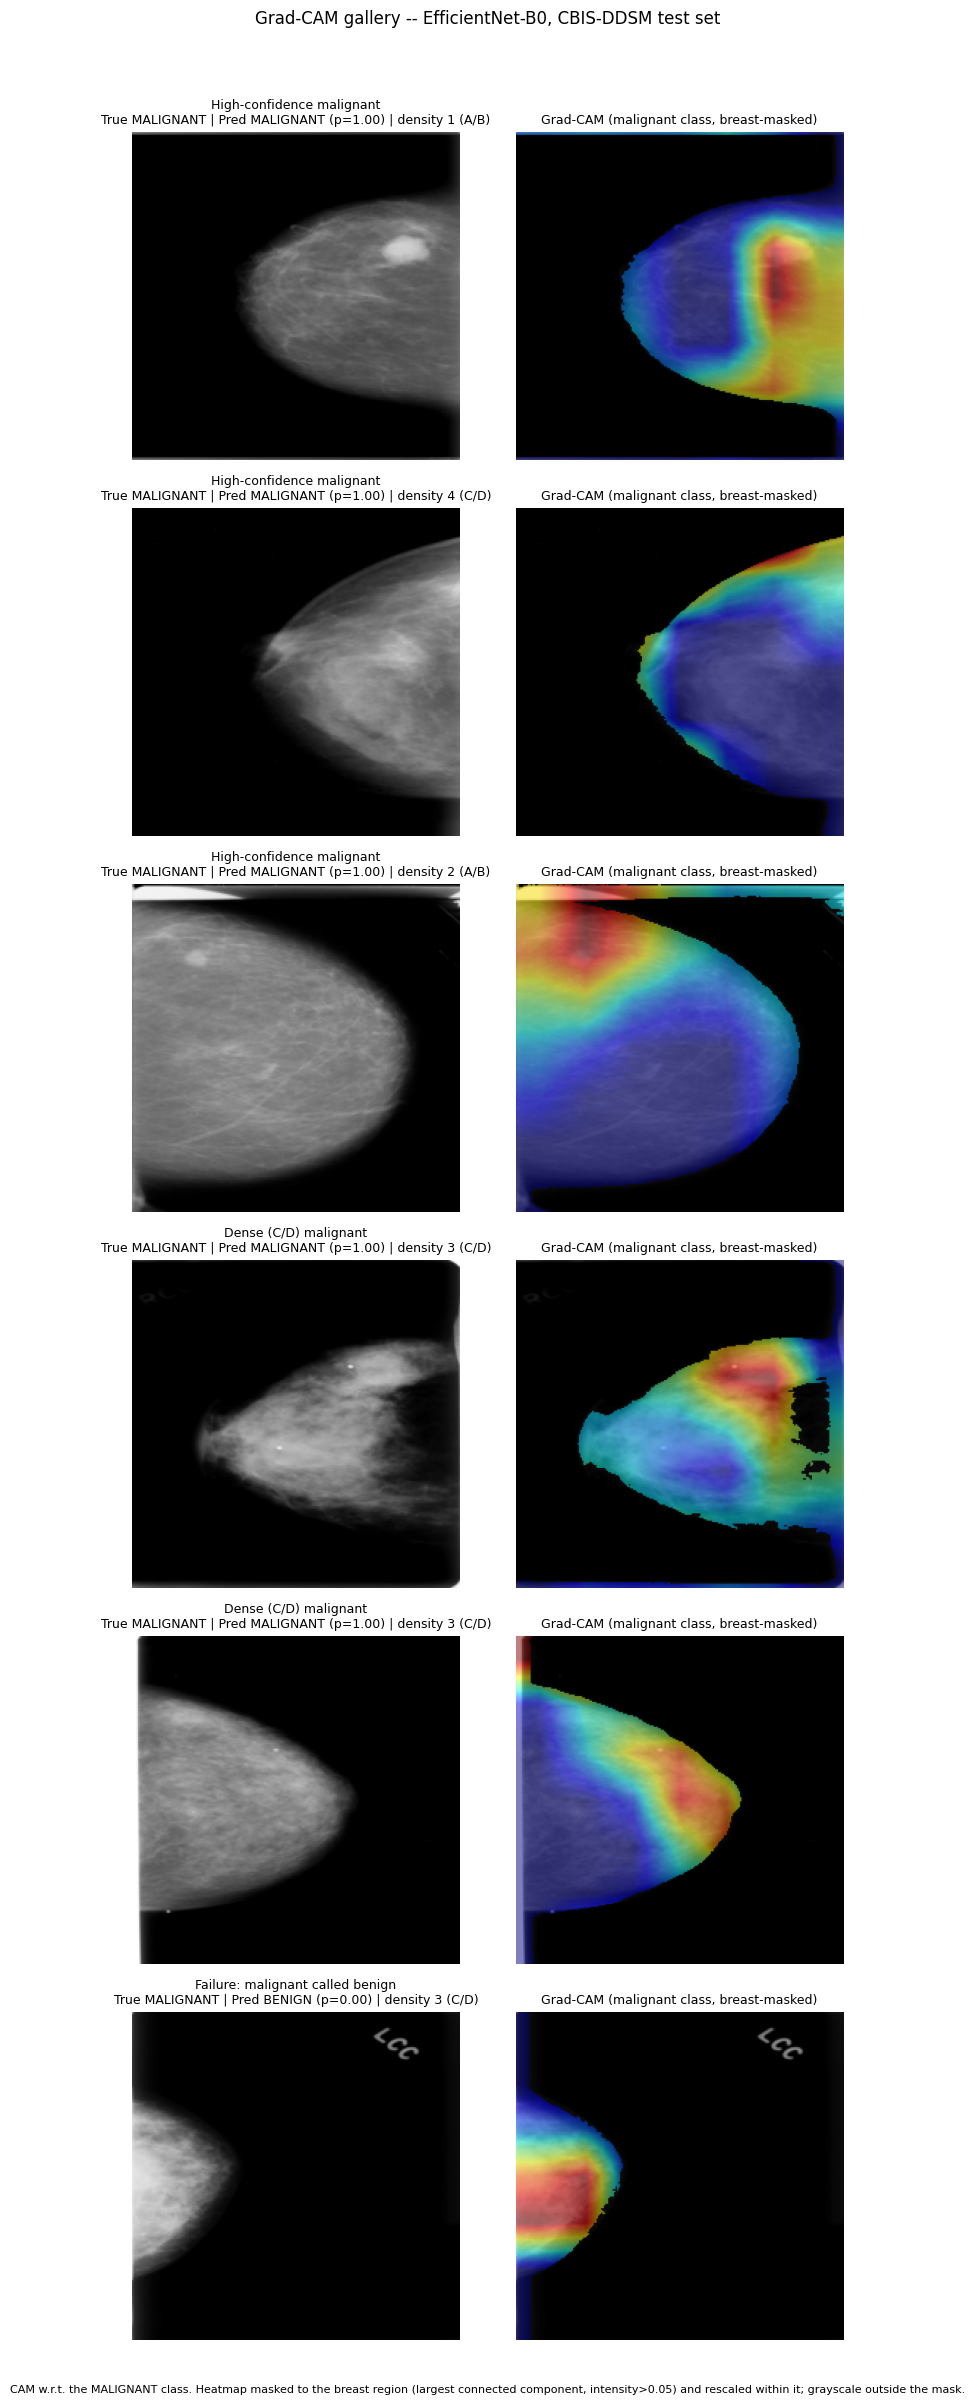

Saved -> /content/drive/MyDrive/MammoLens/results/gradcam_gallery.png


In [ ]:
import os, numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
from scipy import ndimage
from src.data import make_loader
from src.model import build_model
from src.gradcam import GradCAM, last_conv_layer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
POS = cfg.evaluate.positive_class
MEAN = np.array([0.485, 0.456, 0.406]); STD = np.array([0.229, 0.224, 0.225])
MASK_THR = 0.05
RESULTS_DIR = os.path.join(cfg.paths.drive_root, 'initial_run', 'results'); os.makedirs(RESULTS_DIR, exist_ok=True)

# Load best_model.pt explicitly, not whatever happens to be in memory.
ckpt = torch.load(os.path.join(cfg.paths.checkpoint_dir, 'best_model.pt'), map_location=device, weights_only=False)
model = build_model(cfg).to(device); model.load_state_dict(ckpt['model_state']); model.eval()
print(f"Loaded best_model.pt (epoch {ckpt['epoch']+1}, val_auc {ckpt['best_auc']:.4f})")

# Score the whole test set (loader is non-shuffled -> order matches test.csv).
test_loader = make_loader(cfg, 'test'); ds = test_loader.dataset
probs = []
with torch.no_grad():
    for images, _ in test_loader:
        probs.extend(torch.softmax(model(images.to(device)).float(), 1)[:, POS].cpu().numpy())
df = ds.df.copy(); df['prob'] = probs; df['pred'] = (df['prob'] >= 0.5).astype(int)
dgroup = lambda d: 'A/B' if d in (1, 2) else 'C/D'

# Chosen by rule, so I cannot cherry-pick the maps that flatter the model.
correct_mal = df[(df.label == 1) & (df.pred == 1)].sort_values('prob', ascending=False)
sel_a = correct_mal.head(3)                                                   # (a) highest-confidence hits
sel_b = correct_mal[correct_mal.density.isin([3, 4])
                    & ~correct_mal.index.isin(sel_a.index)].head(2)           # (b) dense (C/D) hits
sel_c = df[(df.label == 1) & (df.pred == 0)].sort_values('prob').head(1)      # (c) most confident miss
selected = ([('High-confidence malignant', i) for i in sel_a.index]
            + [('Dense (C/D) malignant', i) for i in sel_b.index]
            + [('Failure: malignant called benign', i) for i in sel_c.index])
print(f"Cases: {len(sel_a)} high-conf, {len(sel_b)} dense, {len(sel_c)} failure")

cam_engine = GradCAM(model, last_conv_layer(model))
LBL = {0: 'BENIGN', 1: 'MALIGNANT'}
nrows = len(selected)
fig, axes = plt.subplots(nrows, 2, figsize=(8, 4 * nrows))
if nrows == 1: axes = axes[None, :]

for r, (tag, idx) in enumerate(selected):
    img_t, _ = ds[idx]
    cam = cam_engine(img_t.unsqueeze(0).to(device), class_idx=POS)   # CAM for MALIGNANT class
    disp = np.clip(img_t.numpy().transpose(1, 2, 0) * STD + MEAN, 0, 1)
    gray = disp.mean(2)

    m = gray > MASK_THR                                             # breast = largest non-black blob
    lbl, n = ndimage.label(m)
    if n > 0:
        sizes = ndimage.sum(np.ones_like(lbl), lbl, range(1, n + 1))
        m = lbl == (np.argmax(sizes) + 1)
    cam_m = cam * m
    if cam_m.max() > 0: cam_m = cam_m / cam_m.max()                 # rescale within breast
    heat = cm.jet(cam_m)[..., :3]
    overlay = disp.copy(); overlay[m] = 0.5 * disp[m] + 0.5 * heat[m]

    row = df.loc[idx]
    axes[r, 0].imshow(disp); axes[r, 0].axis('off')
    axes[r, 0].set_title(f"{tag}\nTrue {LBL[row.label]} | Pred {LBL[row.pred]} "
                         f"(p={row.prob:.2f}) | density {row.density} ({dgroup(row.density)})", fontsize=9)
    axes[r, 1].imshow(overlay); axes[r, 1].axis('off')
    axes[r, 1].set_title('Grad-CAM (malignant class, breast-masked)', fontsize=9)

fig.suptitle('Grad-CAM gallery -- EfficientNet-B0, CBIS-DDSM test set', fontsize=12, y=0.997)
fig.text(0.5, 0.004, f'CAM w.r.t. the MALIGNANT class. Heatmap masked to the breast region '
         f'(largest connected component, intensity>{MASK_THR}) and rescaled within it; grayscale outside the mask.',
         ha='center', fontsize=8)
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
out = os.path.join(RESULTS_DIR, 'gradcam_gallery.png')
fig.savefig(out, dpi=160, bbox_inches='tight'); plt.show()
print('Saved ->', out)

<a id="f2"></a>
**Figure 2.** Grad-CAM gallery for six test images selected by rule from the predictions of `best_model.pt`. Left: the input after resizing to 224 by 224 pixels, titled with the selection group, the true and predicted label, the predicted malignant probability and the BI-RADS density. Right: Grad-CAM for the malignant class, masked to the breast region and rescaled within it. Rows 1 to 3 are the highest-confidence correct malignant calls, rows 4 and 5 the most confident correct calls in dense (C/D) breasts, and row 6 the most confident miss. Saved as `initial_run/results/gradcam_gallery.png`.

The printed lines confirm that `best_model.pt` was saved at epoch 12 with a validation AUC of 0.7543, and that my selection rule filled all six slots: three high-confidence, two dense, one failure.

Figure 2 is a set of individual examples, not evidence about how the model behaves in general. All five correct cases were called malignant with a displayed probability of 1.00 and the failure was given 0.00, so the gallery only shows me the extremes of the model's confidence and not the uncertain middle. Within those limits the maps are a mixed picture. In row 1 (BI-RADS 1) the strongest response sits close to the bright, well-defined opacity in the upper breast, which is the pattern I was hoping for. Row 3 (BI-RADS 2) peaks in the upper breast near a small bright spot, but the high-response region also runs onto a bright strip along the top edge of the image, outside the breast, which my mask failed to remove. Row 5 shows a similar coloured strip along the left border. In row 2 (BI-RADS 4) the response concentrates along the upper margin of the breast rather than on anything I can identify. In row 4 (BI-RADS 3) the peak falls on dense tissue containing small bright foci, but a map this coarse over dense tissue cannot confirm those foci are the lesion.

The failure in row 6 (BI-RADS 3) is interesting for a different reason. The breast occupies a narrow region at the left of the resized image, next to a large dark background and a burnt-in "LCC" view label, so after resizing there is very little tissue left in pixels. The map spreads over most of the visible breast without settling anywhere. One plausible reading is that too little resolved tissue remained for the model to work with, though a single case cannot separate that from other explanations.

I did not check any of this against the ROI masks CBIS-DDSM supplies, so this notebook has no quantitative measure of whether my Grad-CAM peaks fall on annotated lesions. Saliency methods can also produce convincing maps that barely depend on the model's learned weights (Adebayo et al., 2018), and I ran no such sanity check. What Figure 2 supports is a modest claim: my model's malignant-class evidence sometimes coincides with a visible abnormality and sometimes with the image borders. It does not support the claim that the model has learned to localise cancer.

<a id="s7"></a>
## 7 Limitations

Everything here rests on one training run with one seed, one data split and a single test set of 400 images. I produced no confidence intervals, no significance tests and no repeated splits in the original run, so Sections 5 and 6 give point estimates with no measure of their precision, and Sections 5.6 and 5.7 were my attempt to fix that afterwards. The density comparison inherits the same weakness at a finer scale. Its two groups hold 90 and 79 malignant images, and the supplementary categories go down to 38 images in total. Model selection is exposed too, because it relied on a validation set of 405 images with only 9 malignant images at BI-RADS 4 (Table 3).

CBIS-DDSM is a curated subset of DDSM, a collection of digitised screen-film mammograms (Heath et al., 2001; Lee et al., 2017). Every image in it contains at least one annotated abnormality, so what I am really studying is telling benign from malignant findings, not finding cancer among the mostly normal examinations of a screening programme. Nothing here says how the model would do on modern digital mammography or in a screening population. Because I re-split the pooled official train and test files (Section 3.1), my figures also cannot be set directly beside published results on the official test split.

Several preprocessing choices were made for simplicity and never tested. Downsampling full mammograms of several thousand pixels per side (Table 1c) to 224 by 224 is likely to erase fine structures such as microcalcifications, which matters because calcification cases make up part of my data. The resize also distorts the aspect ratio (Section 3.2). Labels are assigned per image by the any-malignant rule, and I merged the two benign categories.

The density analysis cannot separate density from other characteristics of the cases. My manifest keeps only path, label, density and patient, so abnormality type, subtlety and BI-RADS assessment, all sitting in the raw files (Table 1), were not available for me to check whether my dense and non-dense groups differ in case mix.

Sensitivity and specificity in Section 5 are reported at the default decision rule rather than at an operating point chosen on validation data, which Section 5.7.3 addresses. Grad-CAM was assessed on six rule-selected, high-confidence cases by eye alone, with no comparison against ROI masks and no saliency sanity checks (Section 6.1).

The notebook itself is an incomplete record, and I would rather say so than leave it to be noticed. Most code cells carry no execution count, which means the outputs came from more than one session. The per-epoch training log is missing because training ran in an earlier session (Section 4.1), which is a mistake I corrected in the later runs by logging every epoch to a CSV. And the code comment in Section 3.3 quotes timings that no output supports; Section 5.6.5 measures them properly and the local copy turns out to help far less than that comment claims. The counts that recur across cells, 2857 images, 400 test images and 169 malignant test images, agree everywhere they appear, which suggests the outputs did come from the same manifests. That is reassuring, but it is not the same as one clean top-to-bottom run.

<a id="s8"></a>
## 8 References

Adebayo, J., Gilmer, J., Muelly, M., Goodfellow, I., Hardt, M. and Kim, B. (2018) 'Sanity checks for saliency maps', in *Advances in Neural Information Processing Systems 31 (NeurIPS 2018)*, pp. 9505-9515.

Boyd, N.F., Guo, H., Martin, L.J., Sun, L., Stone, J., Fishell, E., Jong, R.A., Hislop, G., Chiarelli, A., Minkin, S. and Yaffe, M.J. (2007) 'Mammographic density and the risk and detection of breast cancer', *New England Journal of Medicine*, 356(3), pp. 227-236. doi:10.1056/NEJMoa062790.

Deng, J., Dong, W., Socher, R., Li, L.-J., Li, K. and Fei-Fei, L. (2009) 'ImageNet: a large-scale hierarchical image database', in *2009 IEEE Conference on Computer Vision and Pattern Recognition*. Miami, FL: IEEE, pp. 248-255. doi:10.1109/CVPR.2009.5206848.

D'Orsi, C.J., Sickles, E.A., Mendelson, E.B. and Morris, E.A. (2013) *ACR BI-RADS Atlas: Breast Imaging Reporting and Data System*. 5th edn. Reston, VA: American College of Radiology.

Heath, M., Bowyer, K., Kopans, D., Moore, R. and Kegelmeyer, P. (2001) 'The Digital Database for Screening Mammography', in Yaffe, M.J. (ed.) *Proceedings of the Fifth International Workshop on Digital Mammography*. Madison, WI: Medical Physics Publishing, pp. 212-218.

Kaufman, S., Rosset, S., Perlich, C. and Stitelman, O. (2012) 'Leakage in data mining: formulation, detection, and avoidance', *ACM Transactions on Knowledge Discovery from Data*, 6(4), Article 15. doi:10.1145/2382577.2382579.

Lee, R.S., Gimenez, F., Hoogi, A., Miyake, K.K., Gorovoy, M. and Rubin, D.L. (2017) 'A curated mammography data set for use in computer-aided detection and diagnosis research', *Scientific Data*, 4, Article 170177. doi:10.1038/sdata.2017.177.

Loshchilov, I. and Hutter, F. (2017) 'SGDR: stochastic gradient descent with warm restarts', in *5th International Conference on Learning Representations (ICLR 2017)*. Toulon, France.

Loshchilov, I. and Hutter, F. (2019) 'Decoupled weight decay regularization', in *7th International Conference on Learning Representations (ICLR 2019)*. New Orleans, LA.

Micikevicius, P., Narang, S., Alben, J., Diamos, G., Elsen, E., Garcia, D., Ginsburg, B., Houston, M., Kuchaiev, O., Venkatesh, G. and Wu, H. (2018) 'Mixed precision training', in *6th International Conference on Learning Representations (ICLR 2018)*. Vancouver, Canada.

Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., Killeen, T., Lin, Z., Gimelshein, N., Antiga, L., Desmaison, A., Köpf, A., Yang, E., DeVito, Z., Raison, M., Tejani, A., Chilamkurthy, S., Steiner, B., Fang, L., Bai, J. and Chintala, S. (2019) 'PyTorch: an imperative style, high-performance deep learning library', in *Advances in Neural Information Processing Systems 32 (NeurIPS 2019)*, pp. 8024-8035.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. and Duchesnay, É. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825-2830.

Raghu, M., Zhang, C., Kleinberg, J. and Bengio, S. (2019) 'Transfusion: understanding transfer learning for medical imaging', in *Advances in Neural Information Processing Systems 32 (NeurIPS 2019)*, pp. 3347-3357.

Selvaraju, R.R., Cogswell, M., Das, A., Vedantam, R., Parikh, D. and Batra, D. (2017) 'Grad-CAM: visual explanations from deep networks via gradient-based localization', in *2017 IEEE International Conference on Computer Vision (ICCV)*. Venice: IEEE, pp. 618-626. doi:10.1109/ICCV.2017.74.

Tan, M. and Le, Q.V. (2019) 'EfficientNet: rethinking model scaling for convolutional neural networks', in *Proceedings of the 36th International Conference on Machine Learning*. PMLR 97, pp. 6105-6114.

Wightman, R. (2019) *PyTorch Image Models* [computer program]. Available at: https://github.com/huggingface/pytorch-image-models (Accessed: [DATE]).